# Prithvi-EO-1.0 multi-temporal crop classification — DIMER E2E segmentation fine-tuning tutorial (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/prithvi-crop-classification-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/prithvi-crop-classification-pipeline/blob/main/tutorials/prithvi_crop_classification_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-ibm--nasa--geospatial%2FPrithvi--EO--1.0--100M--multi--temporal--crop--classification-ffcc4d?style=flat)](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification) [![Upstream](https://img.shields.io/badge/Upstream-NASA--IMPACT%2Fhls--foundation--os-181717?style=flat&logo=github&logoColor=white)](https://github.com/NASA-IMPACT/hls-foundation-os) [![Paper](https://img.shields.io/badge/arXiv-2310.18660-b31b1b.svg)](https://arxiv.org/abs/2310.18660)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.0 — **standalone** (§4)  
**Capability:** 13-class crop and land-cover segmentation of three-date six-band HLS chips with a Prithvi-EO-1.0 temporal ViT encoder, held-out IoU/accuracy against a majority-class baseline, and bounded fine-tuning of the segmentation head to labelled chips

**This notebook is standalone.** It carries the repository's package (4 modules under `src/prithvi_crop_classification_pipeline/`, at revision `a3faec8ac4e4`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `b53a88b8da673800b67c34a98a527b77076e7035` (~1680 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.2); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh **GPU** runtime builds an isolated environment from the hash-locked pins (torch, tifffile, numpy, safetensors, huggingface-hub — no mmcv, mmsegmentation or timm: the network is carried in this notebook); nothing is installed into the notebook's own Python, so no restart is needed and Run all completes in one pass. It then stages and digest-verifies the pinned Prithvi crop-classification checkpoint (1.68 GB) from the Hub, statically audits the mmsegmentation pickle against an allow-list, converts it once into safetensors with a pinned digest (keeping the 98 inference tensors and dropping the training-only auxiliary head and the optimizer state), rebuilds the network from the carried module and loads it strictly, fetches the digest-pinned dataset tarball (1.18 GB, no credential) and extracts exactly the 120 pinned chip and mask members, validates them and assigns roles by spatial block (36 training, 12 validation, 12 test), classifies the held-out chips with the frozen model and scores them against the majority-class baseline, runs a bounded fine-tuning of the segmentation head, scores the same chips again, writes class maps for two held-out chips, exports the adapter as safetensors with a manifest, and reloads that artifact into a fresh pipeline to verify prediction parity. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.0 §5). On a T4 the whole path takes a few minutes of model time after the downloads; the tarball and the adaptation are the slowest steps.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell to supply your own labelled chips — as `BYOD_PATH` (a path in the runtime, which works on Colab, Kaggle and Jupyter) or, when it is empty, through the Colab upload dialog — as a zip (or folder) holding `pairs.csv` (columns `id`, `image`, `label`) beside 18-band 224 × 224 GeoTIFF chips (three dates × six HLS bands — blue, green, red, narrow NIR, SWIR 1, SWIR 2 — date-major, surface reflectance × 10 000) and single-band label rasters (0 = no data, 1..13 = the classes in the order the model uses); at least **7** labelled chips with at least two classes (the seeded 25 % test / 20 % validation split must leave the 4 training chips adaptation needs; Section 4 prints the minimum and refuses a smaller set by name). An optional `group` column (a field, scene or region id) keeps every chip of one group in one role, so neighbouring chips of one field cannot sit on both sides of the split. Your chips flow through the same contract — validation, frozen baseline, adaptation, held-out evaluation, class maps, artifact export and reload parity — and Section 5 puts the model back to the pinned base first, so the frozen numbers on your chips are the packaged model's. The expected schema, the ceilings and the privacy guidance are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

Prithvi-EO-1.0-100M (Jakubik et al., 2023) is NASA and IBM's first foundation model for Harmonized Landsat Sentinel-2 imagery: a ViT-B masked autoencoder pretrained on three-date stacks of six bands over the contiguous United States. The checkpoint packaged here is the upstream authors' fine-tune for multi-temporal crop classification — the first six encoder blocks, a transposed-convolution neck that folds the three dates into one 16×-upsampled feature map, and an FCN head over 13 classes derived from the USDA Cropland Data Layer — trained with mmsegmentation on 224 × 224 chips of three 2022 growing-season dates.

Three things about this row are handled in the open. **The upstream asset is a pickle** — an mmsegmentation checkpoint holding the state dict, the Adam optimizer state and a `meta` record. Section 3 downloads and digest-verifies it, statically lists every global the pickle would import (a state dict of tensors, plus the three data-only names that rebuild one numpy scalar in `meta`), refuses anything outside that allow-list, unpickles it exactly once through torch's weights-only loader with those three names bound to inert stand-ins, keeps the 98 inference tensors and writes a safetensors file whose digest is pinned in the carried module; the network you run is rebuilt from `modeling.py`, carried in this notebook in plain PyTorch, and loads that file strictly. **The dataset ships as one 1.18 GB tarball**, so Section 4 pins it by size and digest, streams through it once and copies out exactly the 120 pinned members (each pinned again by size and digest, no `extractall`, no paths taken from the archive), and leaves the other 1,422 alone. **The model was selected on these chips**: every chip in the archive belongs to the upstream validation split, on which the published checkpoint's best epoch was chosen, so the bounded adaptation in Section 6 is a demonstration of the contract, selected by validation loss with the frozen model as epoch 0; the point of the contract is the same recipe applied to *your* labelled chips.

**Learning objectives:** install the pinned runtime; inspect the carried network, pipeline, dataset and metrics modules; stage and digest-verify a pickled checkpoint, read its static audit and see it converted into safetensors; extract pinned members from a digest-verified tarball and validate real labelled multispectral time series with an ignore class; read per-class IoU, mean IoU, mean class accuracy and overall accuracy against a majority-class baseline; run a bounded fine-tuning of the segmentation head with the upstream class-weighted loss, explicit hyperparameters and frozen BatchNorm statistics; compare the adapted and frozen models on the same held-out chips; write class maps; and export a safetensors adapter that reloads against the pinned base with verified parity.

**This notebook does not demonstrate:** yield estimation, field delineation, dates other than three, chips other than 224 × 224 (tiling is the caller's), cloud masking, the published benchmark scores, the 12-block Prithvi-EO-1.0 encoder (this fine-tune keeps six blocks), and any claim that a 60-chip sample stands in for an operational evaluation. The repository exposes none of these.

**Who this notebook is for.** The intended audience is a learner who knows basic Python, has used Colab or Jupyter, and wants to see how a multi-temporal Earth-observation model that names 13 crop and land-cover classes is evaluated and adapted honestly: how its class maps are scored per class against the best constant map, what a bounded fine-tuning of its head does to a model selected on the very chips used here, and how the change is exported and reloaded. No prior experience with Prithvi, mmsegmentation or remote sensing models is assumed; terms are explained where they first matter and again in the **Glossary** at the end. A GPU runtime (T4 or better) is expected.

**Input → Model → Output.**

| | Classification | Bounded fine-tuning |
|---|---|---|
| Input | 224 × 224 chips of three 2022 dates × six HLS bands (digital numbers) | labelled chips with 13 classes and −1 for no data (36 training, 12 validation, 12 test, split by 4 × 4-chip block) |
| Model | the Prithvi-EO-1.0 temporal ViT encoder (six blocks), a transposed-convolution neck and an FCN head, carried in plain PyTorch and loaded from audited, converted safetensors | the same network; only the FCN head (5.3 M parameters) is trained with the upstream class weights, encoder, neck and BatchNorm statistics stay frozen |
| Output | a per-pixel class map (0..12), softmax scores and class fractions; per-class IoU, mean IoU and accuracy beside the majority-class baseline | the adapted model's numbers beside the frozen model's on the same held-out chips, and a 21 MB safetensors adapter that reloads with parity |

**How to use this notebook.** Choose a GPU runtime (**Runtime → Change runtime type → T4 GPU**), then **Runtime → Run all**. Run all completes in one pass: Section 1 installs nothing into the notebook's own Python, so no restart is needed. Sections 1–3 are **infrastructure** — the isolated environment, the carried network and package, and the audited model snapshot — and their cells are collapsed; you may run them without studying them. The learning path starts in Section 4. Form fields (`# @param`) are the only values meant to be edited, and the defaults reproduce the recorded run. Before each principal result the notebook asks you to **Predict**; after it come **What to notice** and a collapsible **Check your reasoning** with a worked answer from the recorded run (the Kaggle Tesla T4 run of 20 September 2026 recorded in `docs/release-verification.md`). Every adaptation starts from the pinned base, so re-running Section 6 with other settings is a fresh experiment. **Troubleshooting**, a **Glossary** and a **Conclusion** template are at the end. Writing your predictions down is optional.

**Roadmap:** 1–3 infrastructure → 4 the labelled chips, block split, validation and refusals *(evaluation practice)* → 5 the frozen model against the majority-class baseline *(core concept)* → 6 bounded fine-tuning of the segmentation head *(core concept)* → 7 the held-out paired comparison with per-chip numbers *(evaluation practice)* → 8 class maps shown inline, export and fresh reload *(engineering)* → interpretation, an optional experiment, troubleshooting, glossary and your conclusion.

## Prerequisites

- **Runtime:** a fresh supported **GPU** runtime (Google Colab T4 or better, or a Jupyter kernel with a CUDA GPU and Python 3.12): the network runs in float16 autocast and the default adaptation needs about 4 GB of GPU memory; on CPU one chip takes several seconds and the adaptation would take an hour. About 4.5 GB of disk is needed for the checkpoint, its conversion and the tarball.
- **Knowledge:** what a multispectral surface-reflectance chip is (bands, dates, digital numbers, no-data), what a pixel-wise class map and an ignore class are, and how per-class IoU and mean IoU are read against a majority baseline.
- **Executable serialization handled explicitly:** the pinned checkpoint is a pickle. It is digest-verified, statically audited against an allow-list (audit digest pinned) and unpickled **once** through torch's weights-only loader — with the three data-only numpy names of its `meta` record bound to inert stand-ins — to produce the safetensors the network is actually loaded from. No Hub-hosted Python module is imported and no mmsegmentation code runs; the network is the carried `modeling.py`.
- **Data contract:** a record is `{id, image, label}` — a (3, 6, 224, 224) array of three dates × six HLS bands in digital numbers (reflectance × 10 000; an array in [0, 1] is scaled) or an 18-band date-major GeoTIFF, and a (224, 224) mask with classes 0..12 and −1 for no data (or a GeoTIFF with 0 = no data, 1..13 = class). Validation is structural: nothing checks that the bands are the right six in the right order, that the three dates are growing-season dates, or that the label belongs to the chip.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — field-level records tied to a producer or commercial imagery under licence are exactly that. The default path uploads nothing.
- **External access (data):** besides the model snapshot, the default path fetches one pinned object — the 1.18 GB `validation_chips.tgz` of the Hugging Face dataset `ibm-nasa-geospatial/multi-temporal-crop-classification` at an immutable revision — over HTTPS, digest-verified before any member is read; the dataset is CC BY 4.0 (NASA IMPACT / IBM).
- **External access:** the Hugging Face Hub only, to fetch the pinned `ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification` snapshot (~1680 MB in total) at revision `b53a88b8da67…`. No GitHub access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 44 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

Hosted runtimes such as Colab and Kaggle import some packages, NumPy and often PyTorch among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env_<lock digest>/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 44 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins in the cell) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message.

The same cell then starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. It is the only cell that runs in the kernel (it is marked `# dimer: kernel cell`), and it is safe to re-run: a complete environment built from this exact lock is reused rather than rebuilt, and a live worker is kept with every variable created so far, so the cells after it keep working. To start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Infrastructure: build (or reuse) the isolated environment and route later cells to it
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import signal
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from multiprocessing.connection import Connection
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'tifffile==2026.9.15',
    'numpy==2.5.3',
    'safetensors==0.8.0',
    'huggingface-hub==1.32.0',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = '3b098a1191b06afee15b1038dd60c0cfdd48375ee24debdf7ac4fbdfc9bc6b54'
LOCKED_PACKAGES = 44
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
anyio==4.15.1 \
    --hash=sha256:6152fdbbf9a77fdec97731721bebf7c4c44f7c29b424b0065826173efc7ed101 \
    --hash=sha256:9f28306018cbd6d329e64a36d58256edff76dd996fe423bc957326e578b82a94
    # via httpx
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   httpcore
    #   httpx
click==8.5.0 \
    --hash=sha256:255bc9599cf7748b4b1a446ccc735421bd08a2ae529a8b88597d3de5664ee360 \
    --hash=sha256:ba0d2089de75ea0310e2dde03160e6ca10009947fb95a182f9b54021bb272e34
    # via huggingface-hub
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via torch
cuda-pathfinder==1.8.3 \
    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f
    # via cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via torch
filelock==4.0.12 \
    --hash=sha256:5f17ee83ecee8a6f3e389c75822fb70a1c2f0506b99438a6dffa1d56793588c8 \
    --hash=sha256:cf42711a7ac791818b299fab0332a088c65aeeefa36290de98db92c434303b0c
    # via
    #   huggingface-hub
    #   torch
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   huggingface-hub
    #   torch
h11==0.16.0 \
    --hash=sha256:4e35b956cf45792e4caa5885e69fba00bdbc6ffafbfa020300e549b208ee5ff1 \
    --hash=sha256:63cf8bbe7522de3bf65932fda1d9c2772064ffb3dae62d55932da54b31cb6c86
    # via httpcore
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via huggingface-hub
httpcore==1.0.9 \
    --hash=sha256:2d400746a40668fc9dec9810239072b40b4484b640a8c38fd654a024c7a1bf55 \
    --hash=sha256:6e34463af53fd2ab5d807f399a9b45ea31c3dfa2276f15a2c3f00afff6e176e8
    # via httpx
httpx==0.28.1 \
    --hash=sha256:75e98c5f16b0f35b567856f597f06ff2270a374470a5c2392242528e3e3e42fc \
    --hash=sha256:d909fcccc110f8c7faf814ca82a9a4d816bc5a6dbfea25d6591d6985b8ba59ad
    # via huggingface-hub
huggingface-hub==1.32.0 \
    --hash=sha256:b0c7c80561969d9cdacdd55fce67ba9584cca0b9d4ea80957a3a5c1445fac5c8 \
    --hash=sha256:ed70a45498abe86039df7c2f4e5f7575de524be908d3840e8f828d5525eafd6a
    # via prithvi-crop-classification-pipeline (pyproject.toml)
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   anyio
    #   httpx
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via torch
markupsafe==3.0.4 \
    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \
    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \
    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \
    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \
    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \
    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \
    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \
    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \
    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \
    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \
    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \
    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \
    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \
    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \
    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \
    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \
    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \
    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \
    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \
    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \
    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \
    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \
    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \
    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \
    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \
    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \
    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \
    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \
    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \
    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \
    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \
    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \
    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \
    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \
    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \
    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \
    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \
    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \
    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \
    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \
    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \
    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \
    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \
    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \
    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \
    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \
    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \
    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \
    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \
    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \
    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \
    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \
    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \
    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \
    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \
    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \
    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \
    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \
    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \
    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \
    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \
    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \
    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \
    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \
    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \
    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \
    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \
    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \
    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \
    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \
    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \
    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \
    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \
    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \
    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \
    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \
    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \
    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \
    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \
    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \
    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \
    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \
    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \
    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \
    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \
    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \
    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \
    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \
    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \
    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \
    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \
    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \
    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \
    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \
    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \
    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \
    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \
    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \
    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \
    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \
    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \
    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \
    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \
    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \
    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \
    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \
    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \
    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \
    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \
    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \
    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \
    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \
    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \
    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \
    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \
    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \
    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \
    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \
    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \
    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \
    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \
    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \
    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \
    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \
    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \
    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \
    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \
    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \
    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \
    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \
    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \
    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \
    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \
    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \
    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \
    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \
    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \
    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \
    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \
    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \
    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \
    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \
    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \
    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \
    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \
    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \
    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \
    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \
    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \
    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \
    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3
    # via jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   prithvi-crop-classification-pipeline (pyproject.toml)
    #   tifffile
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via huggingface-hub
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via huggingface-hub
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via prithvi-crop-classification-pipeline (pyproject.toml)
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via torch
tifffile==2026.9.15 \
    --hash=sha256:2ad086262b5bd3b3804f2d044926e5f63d8f6ae72b235d8b774f164b79f587c4 \
    --hash=sha256:9a4a74671c72645e0d48372ff2d20ec1625b1cd52067a72fbd021435dd044794
    # via prithvi-crop-classification-pipeline (pyproject.toml)
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via prithvi-crop-classification-pipeline (pyproject.toml)
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via huggingface-hub
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   anyio
    #   huggingface-hub
    #   torch
'''

SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'
# One environment per lock digest: a re-run of this cell, or a second Run all in the same runtime, reuses a complete
# environment built from this exact lock instead of rebuilding it; a different lock gets a different folder.
ISOLATED_ENV = Path(os.environ.get('DIMER_ISOLATED_ENV', 'dimer_isolated_env_' + LOCK_SHA256[:12])).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / 'bin' / 'python'
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + '_tools')
ISOLATED_READY = ISOLATED_ENV / '.dimer-lock-sha256'


def _isolated_environment_ready():
    return ISOLATED_PYTHON.is_file() and ISOLATED_READY.is_file() and ISOLATED_READY.read_text(encoding='utf-8').strip() == LOCK_SHA256


if SKIP_INSTALL:
    print('DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.')
elif _isolated_environment_ready():
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': True, 'lock_sha256': LOCK_SHA256[:16] + '...', 'locked_packages': LOCKED_PACKAGES, 'kernel_python': platform.python_version()})
else:
    if platform.system() != 'Linux' or platform.machine() != 'x86_64':
        raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.')
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode('utf-8')).hexdigest() != LOCK_SHA256:
        raise RuntimeError('The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.')
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding='utf-8', newline='\n')
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError('The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.')
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
        uv = ISOLATED_TOOLS / 'uv'
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ, MPLBACKEND='Agg')
    for name in ('PYTHONPATH', 'PYTHONHOME', 'PYTHONSTARTUP'):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), 'venv', '--quiet', '--managed-python', '--python', MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), '-c', 'import platform; print(platform.python_version())'], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f'{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.')
    ISOLATED_READY.unlink(missing_ok=True)
    subprocess.run([str(uv), 'pip', 'install', '--quiet', '--python', str(ISOLATED_PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(lock_path)], env=uv_env, check=True)
    ISOLATED_READY.write_text(LOCK_SHA256 + '\n', encoding='utf-8')
    print({'isolated_environment': str(ISOLATED_ENV), 'reused': False, 'isolated_python': isolated_version, 'kernel_python': platform.python_version(), 'locked_packages': LOCKED_PACKAGES, 'setup_seconds': round(time.perf_counter() - setup_started)})

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    import importlib.machinery

    def _stub(name, package):
        # A spec on every stub: importlib.util.find_spec("google.colab") (accelerate does this) raises on a None __spec__.
        module = types.ModuleType(name)
        module.__spec__ = importlib.machinery.ModuleSpec(name, None, is_package=package)
        if package:
            module.__path__ = []
        return module

    try:
        import google
    except ImportError:
        google = _stub("google", True)
        sys.modules["google"] = google
    _colab = _stub("google.colab", True)
    _files = _stub("google.colab.files", False)
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        self.python = str(python)
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def alive(self):
        return self.proc.poll() is None

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]

if SKIP_INSTALL:
    print('Routing disabled: the notebook runs in this kernel.')
else:
    from IPython import get_ipython as _kernel_shell

    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [t for t in _ip.input_transformers_cleanup if getattr(t, '__name__', '') != '_route_to_isolated_runtime']
    # Idempotent: a live worker on this environment is kept, with every variable the later cells created, so
    # re-running this cell alone never strands the cells after it. A dead or different worker is replaced.
    _previous = globals().get('_DIMER_ISOLATED_RUNTIME')
    _reuse = _previous is not None and getattr(_previous, 'python', None) == str(ISOLATED_PYTHON) and _previous.proc.poll() is None
    if _reuse:
        _DIMER_ISOLATED_RUNTIME = _previous
    else:
        if _previous is not None and _previous.proc.poll() is None:
            _previous.close()
        _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print({'routed_to': str(ISOLATED_PYTHON), 'worker_pid': _DIMER_ISOLATED_RUNTIME.proc.pid, 'worker_reused': _reuse})

{'isolated_environment': '/content/dimer_isolated_env_3b098a1191b0', 'reused': False, 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 44, 'setup_seconds': 65}
{'routed_to': '/content/dimer_isolated_env_3b098a1191b0/bin/python', 'worker_pid': 1858, 'worker_reused': False}


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `tifffile` versions, and whether CUDA is available.

In [ ]:
# @title Infrastructure: record the runtime
import importlib
import os
import platform
import sys

NOTEBOOK_SOURCE = {
    'repository': 'prithvi-crop-classification-pipeline',
    'repository_revision': 'a3faec8ac4e4ec92b46962b7ee15c90650526a72',
    'embedded_module': 'src/prithvi_crop_classification_pipeline/pipeline.py',
    'embedded_modules': ['src/prithvi_crop_classification_pipeline/metrics.py', 'src/prithvi_crop_classification_pipeline/modeling.py', 'src/prithvi_crop_classification_pipeline/pipeline.py', 'src/prithvi_crop_classification_pipeline/samples.py'],
    'module_sha256': 'f02c1f09ed059d374b3b88c74db07f343c051a6a08300834a5dddf6822ddd4a3',
    'generator': 'build_notebook.py/2.2',
    'notebook_spec': '2.0',
}
import torch, tifffile
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'executable': sys.executable, 'torch': torch.__version__, 'tifffile': tifffile.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'prithvi-crop-classification-pipeline', 'repository_revision': 'a3faec8ac4e4ec92b46962b7ee15c90650526a72', 'embedded_module': 'src/prithvi_crop_classification_pipeline/pipeline.py', 'embedded_modules': ['src/prithvi_crop_classification_pipeline/metrics.py', 'src/prithvi_crop_classification_pipeline/modeling.py', 'src/prithvi_crop_classification_pipeline/pipeline.py', 'src/prithvi_crop_classification_pipeline/samples.py'], 'module_sha256': 'f02c1f09ed059d374b3b88c74db07f343c051a6a08300834a5dddf6822ddd4a3', 'generator': 'build_notebook.py/2.2', 'notebook_spec': '2.0'}, 'python': '3.12.12', 'executable': '/content/dimer_isolated_env_3b098a1191b0/bin/python', 'torch': '2.14.0+cu130', 'tifffile': '2026.9.15', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/prithvi_crop_classification_pipeline/` @ `a3faec8ac4e4`)

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The next 4 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/4:** `src/prithvi_crop_classification_pipeline/metrics.py`

In [ ]:
"""Pixel-level multi-class segmentation metrics for the crop-classification tutorial and its constant baseline.

All numbers are pooled over the labelled pixels of the chips scored together (the ignore index excluded); nothing
here estimates dispersion. Mean IoU and mean class accuracy average over the classes that occur in the labels or
the predictions of the scored set (mmseg's `nanmean` convention), so a class absent from a small sample does not
pull the mean to zero.
"""

from __future__ import annotations

from collections.abc import Sequence
from typing import Any


def confusion_matrix(predictions: Sequence[Any], labels: Sequence[Any], *, num_classes: int, ignore_index: int) -> Any:
    """(num_classes, num_classes) int64 matrix, rows = label, columns = prediction, ignored pixels excluded."""
    import numpy as np

    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for pred, label in zip(predictions, labels, strict=True):
        pred = np.asarray(pred).reshape(-1).astype(np.int64)
        label = np.asarray(label).reshape(-1).astype(np.int64)
        if pred.shape != label.shape:
            raise ValueError(f"prediction shape {pred.shape} != label shape {label.shape}")
        valid = label != ignore_index
        if valid.any():
            index = label[valid] * num_classes + pred[valid]
            matrix += np.bincount(index, minlength=num_classes * num_classes).reshape(num_classes, num_classes)
    return matrix


def metrics_from_confusion(matrix: Any, class_names: Sequence[str]) -> dict[str, Any]:
    import numpy as np

    matrix = np.asarray(matrix, dtype=np.int64)
    total = int(matrix.sum())
    tp = np.diag(matrix).astype(np.float64)
    label_count = matrix.sum(axis=1).astype(np.float64)
    pred_count = matrix.sum(axis=0).astype(np.float64)
    union = label_count + pred_count - tp
    present = union > 0
    with np.errstate(divide="ignore", invalid="ignore"):
        iou = np.where(present, tp / np.where(union > 0, union, 1), np.nan)
        recall = np.where(label_count > 0, tp / np.where(label_count > 0, label_count, 1), np.nan)
        precision = np.where(pred_count > 0, tp / np.where(pred_count > 0, pred_count, 1), np.nan)
        # F1 is defined for every class that occurs in the labels or the predictions; a class the model never
        # predicts (precision undefined) or that never occurs (recall undefined) scores 0 on the missing side.
        p0, r0 = np.nan_to_num(precision, nan=0.0), np.nan_to_num(recall, nan=0.0)
        f1 = np.where(present, 2 * p0 * r0 / np.where((p0 + r0) > 0, p0 + r0, 1), np.nan)
    return {
        "pixels": total,
        "accuracy": round(float(tp.sum() / total), 4) if total else None,
        "mean_iou": round(float(np.nanmean(iou)), 4) if present.any() else None,
        "mean_accuracy": round(float(np.nanmean(recall)), 4) if (label_count > 0).any() else None,
        "mean_f1": round(float(np.nanmean(f1)), 4) if present.any() else None,
        "iou": {name: (round(float(v), 4) if np.isfinite(v) else None) for name, v in zip(class_names, iou, strict=True)},
        "recall": {name: (round(float(v), 4) if np.isfinite(v) else None) for name, v in zip(class_names, recall, strict=True)},
        "label_fraction": {
            name: round(float(v / total), 4) if total else None for name, v in zip(class_names, label_count, strict=True)
        },
        "classes_scored": int(present.sum()),
    }


def segmentation_metrics(
    predictions: Sequence[Any], labels: Sequence[Any], *, class_names: Sequence[str], ignore_index: int
) -> dict[str, Any]:
    """Per-class IoU / recall, mean IoU, mean class accuracy, mean F1 and overall pixel accuracy."""
    matrix = confusion_matrix(predictions, labels, num_classes=len(class_names), ignore_index=ignore_index)
    return metrics_from_confusion(matrix, class_names)


def per_chip_metrics(
    predictions: Sequence[Any],
    labels: Sequence[Any],
    *,
    class_names: Sequence[str],
    ignore_index: int,
    ids: Sequence[str] | None = None,
) -> list[dict[str, Any]]:
    """Mean IoU and accuracy chip by chip (CR-S5): the pooled numbers let large fields dominate; this list shows
    the spread. The mean IoU of a chip averages over the classes present in that chip."""
    out = []
    for index, (pred, label) in enumerate(zip(predictions, labels, strict=True)):
        metrics = segmentation_metrics([pred], [label], class_names=class_names, ignore_index=ignore_index)
        out.append(
            {
                "id": ids[index] if ids is not None else index,
                "mean_iou": metrics["mean_iou"],
                "accuracy": metrics["accuracy"],
                "classes_scored": metrics["classes_scored"],
                "pixels": metrics["pixels"],
            }
        )
    return out


def majority_baseline(labels: Sequence[Any], *, class_names: Sequence[str], ignore_index: int) -> dict[str, Any]:
    """The constant predictor that names every pixel with the most frequent class of the scored labels — the best
    any constant map can do on these pixels — scored on the same pixels as the model."""
    import numpy as np

    counts = np.zeros(len(class_names), dtype=np.int64)
    for label in labels:
        label = np.asarray(label).reshape(-1).astype(np.int64)
        valid = label[label != ignore_index]
        counts += np.bincount(valid, minlength=len(class_names))[: len(class_names)]
    majority = int(counts.argmax())
    predictions = [np.full(np.asarray(label).shape, majority, dtype=np.int64) for label in labels]
    report = segmentation_metrics(predictions, labels, class_names=class_names, ignore_index=ignore_index)
    report["majority_class"] = class_names[majority]
    return report

**Module 2/4:** `src/prithvi_crop_classification_pipeline/modeling.py` (carried verbatim; see the note above)

In [ ]:
"""The Prithvi-EO-1.0-100M multi-temporal crop-classification network in plain PyTorch.

Vendored from the upstream training code (`NASA-IMPACT/hls-foundation-os`, `geospatial_fm/geospatial_fm.py` at
commit `3b6d401f3b4527059af0e44bd640225285e1933d`, Apache-2.0) and from the parts of `mmsegmentation` 0.30 it was
trained with (`FCNHead` with one conv, the `ConvModule` conv→BN→ReLU order), rewritten without `mmcv`, `mmseg`,
`timm` or `einops` so that the served checkpoint is rebuilt from a dependency-free module. The parameter and
buffer names reproduce the upstream state dict exactly (`backbone.*`, `neck.*`, `decode_head.*`), which is how
the conversion can load it with `strict=True`; the training-only `auxiliary_head` is not part of the network.

Architecture (from the pinned `multi_temporal_crop_classification_Prithvi_100M.py` config):

* `TemporalViTEncoder` — a 3-D patch embedding (`Conv3d`, tubelet 1 × 16 × 16) over (bands, dates, H, W), a
  fixed 3-D sin/cos positional embedding plus a class token, 6 pre-norm transformer blocks of width 768 with 8
  heads (MLP ratio 4), and a final LayerNorm; the first 6 blocks of the 12-block Prithvi-EO-1.0-100M masked
  autoencoder, fine-tuned end to end.
* `ConvTransformerTokensToEmbeddingNeck` — drops the class token, folds the (dates × 14 × 14) tokens into a
  (768 × 3, 14, 14) map, and upsamples it 16× through four `ConvTranspose2d` layers (two with a LayerNorm + GELU).
* `FCNHead` — one 3 × 3 conv (2304 → 256) with BatchNorm and ReLU, Dropout2d(0.1), and a 1 × 1 conv to the 13
  crop / land-cover classes, at the input resolution.

The whole network takes a (B, 6, 3, 224, 224) standardised stack — six HLS bands × three dates, in the exact
layout the upstream data pipeline produced (see `pipeline._normalise`) — and returns (B, 13, 224, 224) logits.
"""

from __future__ import annotations

import math

import torch
from torch import nn


def _sincos_1d(embed_dim: int, positions: torch.Tensor) -> torch.Tensor:
    """(M,) positions -> (M, embed_dim) sin/cos table (float64, as the upstream numpy code)."""
    omega = torch.arange(embed_dim // 2, dtype=torch.float64) / (embed_dim / 2.0)
    omega = 1.0 / torch.pow(10000.0, omega)
    out = positions.to(torch.float64).reshape(-1, 1) * omega.reshape(1, -1)
    return torch.cat([torch.sin(out), torch.cos(out)], dim=1)


def sincos_pos_embed_3d(embed_dim: int, grid_size: tuple[int, int, int], *, cls_token: bool) -> torch.Tensor:
    """The fixed 3-D positional embedding of the upstream `get_3d_sincos_pos_embed`: 6/16 of the width for the
    column, 6/16 for the row and 4/16 for the date, concatenated per token in (date, row, column) order, with a
    zero row prepended for the class token."""
    if embed_dim % 16:
        raise ValueError("embed_dim must be a multiple of 16")
    t_size, h_size, w_size = grid_size
    w_dim = h_dim = embed_dim // 16 * 6
    t_dim = embed_dim // 16 * 4
    w_pos = _sincos_1d(w_dim, torch.arange(w_size)).repeat(t_size * h_size, 1)
    h_pos = _sincos_1d(h_dim, torch.arange(h_size)).repeat_interleave(w_size, dim=0).repeat(t_size, 1)
    t_pos = _sincos_1d(t_dim, torch.arange(t_size)).repeat_interleave(h_size * w_size, dim=0)
    pos = torch.cat([w_pos, h_pos, t_pos], dim=1)
    if cls_token:
        pos = torch.cat([torch.zeros(1, embed_dim, dtype=pos.dtype), pos], dim=0)
    return pos.to(torch.float32)


class PatchEmbed(nn.Module):
    """Frames of images to patch embeddings: a Conv3d with kernel = stride = (tubelet, patch, patch)."""

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        num_frames: int = 3,
        tubelet_size: int = 1,
        in_chans: int = 6,
        embed_dim: int = 768,
    ) -> None:
        super().__init__()
        self.img_size = (img_size, img_size)
        self.patch_size = (patch_size, patch_size)
        self.grid_size = (num_frames // tubelet_size, img_size // patch_size, img_size // patch_size)
        self.num_patches = self.grid_size[0] * self.grid_size[1] * self.grid_size[2]
        self.proj = nn.Conv3d(
            in_chans,
            embed_dim,
            kernel_size=(tubelet_size, patch_size, patch_size),
            stride=(tubelet_size, patch_size, patch_size),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _b, _c, _t, height, width = x.shape
        if (height, width) != self.img_size:
            raise ValueError(f"input spatial size {(height, width)} does not match the model's {self.img_size}")
        x = self.proj(x)  # (B, D, T', H', W')
        return x.flatten(2).transpose(1, 2)  # (B, T'·H'·W', D), date-major token order


class Attention(nn.Module):
    """Multi-head self-attention with a fused qkv projection (timm's `Attention`, no q/k norms)."""

    def __init__(self, dim: int, num_heads: int) -> None:
        super().__init__()
        if dim % num_heads:
            raise ValueError("dim must be divisible by num_heads")
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim**-0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, tokens, dim = x.shape
        qkv = self.qkv(x).reshape(batch, tokens, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(batch, tokens, dim)
        return self.proj(x)


class Mlp(nn.Module):
    def __init__(self, dim: int, hidden: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden, dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.act(self.fc1(x)))


class Block(nn.Module):
    """Pre-norm transformer block (timm's `Block` with `qkv_bias=True`, no layer scale, no drop path)."""

    def __init__(self, dim: int, num_heads: int, mlp_ratio: float = 4.0) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)  # upstream passes nn.LayerNorm unchanged: eps 1e-5
        self.attn = Attention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, int(dim * mlp_ratio))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.norm1(x))
        return x + self.mlp(self.norm2(x))


class TemporalViTEncoder(nn.Module):
    """The fine-tuned Prithvi encoder: patch embedding, fixed 3-D positional embedding, class token, blocks."""

    def __init__(
        self,
        img_size: int = 224,
        patch_size: int = 16,
        num_frames: int = 3,
        tubelet_size: int = 1,
        in_chans: int = 6,
        embed_dim: int = 768,
        depth: int = 6,
        num_heads: int = 8,
        mlp_ratio: float = 4.0,
    ) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        self.num_frames = num_frames
        self.patch_embed = PatchEmbed(img_size, patch_size, num_frames, tubelet_size, in_chans, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            sincos_pos_embed_3d(embed_dim, self.patch_embed.grid_size, cls_token=True).unsqueeze(0), requires_grad=False
        )
        self.blocks = nn.ModuleList([Block(embed_dim, num_heads, mlp_ratio) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, T, H, W) -> (B, 1 + T·H'·W', D) normalised tokens, class token first."""
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]
        cls = (self.cls_token + self.pos_embed[:, :1, :]).expand(x.shape[0], -1, -1)
        x = torch.cat((cls, x), dim=1)
        for block in self.blocks:
            x = block(x)
        return self.norm(x)


class Norm2d(nn.Module):
    """LayerNorm over the channel axis of an NCHW map."""

    def __init__(self, embed_dim: int) -> None:
        super().__init__()
        self.ln = nn.LayerNorm(embed_dim, eps=1e-6)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2).contiguous()


class ConvTransformerTokensToEmbeddingNeck(nn.Module):
    """Tokens -> (B, embed_dim, Hp, Wp) map -> 16× upsampled (B, output_embed_dim, 16·Hp, 16·Wp) map through
    four stride-2 transposed convolutions. `embed_dim` is the token width × the number of dates (2304): the
    (dates, Hp, Wp) tokens are folded into the channel axis by a plain reshape, exactly as upstream."""

    def __init__(self, embed_dim: int = 2304, output_embed_dim: int = 2304, hp: int = 14, wp: int = 14) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        self.output_embed_dim = output_embed_dim
        self.hp, self.wp = hp, wp
        self.h_out, self.w_out = hp * 16, wp * 16
        self.fpn1 = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, output_embed_dim, kernel_size=2, stride=2),
            Norm2d(output_embed_dim),
            nn.GELU(),
            nn.ConvTranspose2d(output_embed_dim, output_embed_dim, kernel_size=2, stride=2),
        )
        self.fpn2 = nn.Sequential(
            nn.ConvTranspose2d(output_embed_dim, output_embed_dim, kernel_size=2, stride=2),
            Norm2d(output_embed_dim),
            nn.GELU(),
            nn.ConvTranspose2d(output_embed_dim, output_embed_dim, kernel_size=2, stride=2),
        )

    def forward(self, tokens: torch.Tensor) -> torch.Tensor:
        x = tokens[:, 1:, :]  # drop the class token
        x = x.permute(0, 2, 1).reshape(x.shape[0], -1, self.hp, self.wp)
        x = self.fpn2(self.fpn1(x))
        return x.reshape(-1, self.output_embed_dim, self.h_out, self.w_out)


class ConvModule(nn.Module):
    """mmcv's ConvModule in its default order: conv (no bias) -> BatchNorm -> ReLU."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, padding: int) -> None:
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activate = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.activate(self.bn(self.conv(x)))


class FCNHead(nn.Module):
    """mmseg's FCNHead with `num_convs=1`, `concat_input=False`, `dropout_ratio=0.1`."""

    def __init__(self, in_channels: int = 2304, channels: int = 256, num_classes: int = 13, dropout_ratio: float = 0.1) -> None:
        super().__init__()
        self.convs = nn.Sequential(ConvModule(in_channels, channels, kernel_size=3, padding=1))
        self.dropout = nn.Dropout2d(dropout_ratio)
        self.conv_seg = nn.Conv2d(channels, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv_seg(self.dropout(self.convs(x)))


class PrithviCropSegmenter(nn.Module):
    """Encoder + neck + head: (B, bands, dates, 224, 224) standardised -> (B, num_classes, 224, 224) logits."""

    def __init__(
        self,
        *,
        img_size: int = 224,
        patch_size: int = 16,
        num_frames: int = 3,
        in_chans: int = 6,
        embed_dim: int = 768,
        depth: int = 6,
        num_heads: int = 8,
        head_channels: int = 256,
        num_classes: int = 13,
    ) -> None:
        super().__init__()
        grid = img_size // patch_size
        self.backbone = TemporalViTEncoder(img_size, patch_size, num_frames, 1, in_chans, embed_dim, depth, num_heads)
        self.neck = ConvTransformerTokensToEmbeddingNeck(embed_dim * num_frames, embed_dim * num_frames, grid, grid)
        self.decode_head = FCNHead(embed_dim * num_frames, head_channels, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        logits = self.decode_head(self.neck(self.backbone(x)))
        if tuple(logits.shape[-2:]) != tuple(x.shape[-2:]):  # mmseg resizes the head output to the input size
            logits = nn.functional.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return logits


def parameter_count(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters())


def check_shapes(module: PrithviCropSegmenter) -> dict[str, int]:
    """Sanity numbers used by the tests and the conversion: tensors, parameters and buffers."""
    state = module.state_dict()
    return {
        "tensors": len(state),
        "elements": sum(int(math.prod(v.shape)) for v in state.values()),
        "parameters": parameter_count(module),
    }

**Module 3/4:** `src/prithvi_crop_classification_pipeline/pipeline.py` (carried verbatim; see the note above)

In [ ]:
"""Prithvi-EO-1.0-100M multi-temporal crop classification
(`ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification`) DIMER pipeline: verified snapshot,
one-time conversion of the pickled mmsegmentation checkpoint into safetensors, 13-class crop / land-cover
segmentation of three-date six-band HLS chips, held-out evaluation against a majority-class baseline, and bounded
fine-tuning of the segmentation head to a user's labelled chips with a portable adapter.

Prithvi-EO-1.0-100M (Jakubik et al., 2023) is a ViT-B masked-autoencoder foundation model for Harmonized Landsat
Sentinel-2 imagery, pretrained on three-date stacks. The checkpoint packaged here is the upstream authors'
fine-tune for multi-temporal crop classification: the first six encoder blocks, a transposed-convolution neck and
an FCN head over 13 USDA Cropland Data Layer classes, trained on 224 × 224 chips of three HLS dates (six bands
each) over the contiguous United States in 2022.

The upstream asset is an mmsegmentation checkpoint — a torch zip archive whose pickle holds `meta`, `state_dict`
and the Adam `optimizer` state, and references, besides `collections.OrderedDict`, `torch._utils._rebuild_tensor_v2`
and two storage classes, three data-only globals that rebuild the numpy scalar `meta.hook_msgs.best_score`
(`numpy.core.multiarray.scalar`, `numpy.dtype`, `_codecs.encode`). `audit_pickle` verifies statically that nothing
else is referenced; the conversion then unpickles the file **once** with torch's weights-only unpickler, in which
those three names are bound to inert stand-ins (no numpy code runs and the value is discarded), keeps the 98
inference tensors (the training-only auxiliary head and the optimizer are dropped) after a strict load into the
vendored architecture (`modeling.py`, plain PyTorch, no mmcv / mmseg / timm), and writes safetensors with a
pinned digest — the only file the model is ever loaded from.

Everything model-related is imported lazily so that snapshot verification, the pickle audit and input validation
run (and can refuse) before `torch` is imported (fleet RTM-001). `numpy` and `tifffile` are used for chips and are
imported freely.
"""

from __future__ import annotations

import hashlib
import io
import json
import math
import pickletools
import time
import zipfile
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

MODEL_ID = "ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification"
MODEL_REVISION = "b53a88b8da673800b67c34a98a527b77076e7035"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "prithvi-eo-1.0-100m-crop"
ARTIFACT_FORMAT = "org.valcorza.prithvi-crop-classification.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"

# Immutable upstream source asset (an mmsegmentation checkpoint, i.e. a pickle; see docs/WEIGHTS.md).
SOURCE_CKPT_NAME = "multi_temporal_crop_classification_Prithvi_100M.pth"
SOURCE_CKPT_BYTES = 1_680_468_041
SOURCE_CKPT_SHA256 = "37ed41637eccccec65ca2031324e2c03a4f168e1ea0ea71ad180910589fa018c"
# Code-free serving file produced deterministically by `convert_model` (asset spec §11.2).
CONVERTED_WEIGHTS_NAME = "prithvi-eo-1.0-100m-crop.safetensors"
CONVERTED_SHA256 = "d1df8044700a0d1e00b11b1fbac66e0495cf6647e1632a858c003eaf4b5ce36d"
CONVERTED_BYTES = 537_722_508
# Static-audit digest of the source pickle (sorted global names), see `audit_pickle`.
PICKLE_AUDIT_SHA256 = "465513635354b8c8a9c4bfd4a37b39d5306eb8ec63527905ce0195075d04108d"
TORCH_GLOBALS = frozenset(
    {"collections.OrderedDict", "torch._utils._rebuild_tensor_v2", "torch.FloatStorage", "torch.LongStorage"}
)
# The three data-only globals that rebuild the numpy scalar `meta.hook_msgs.best_score` (the best validation
# mIoU mmseg logged). They construct values, not code, and the conversion binds them to inert stand-ins.
META_GLOBALS = frozenset({"numpy.core.multiarray.scalar", "numpy.dtype", "_codecs.encode"})
CKPT_ALLOWED_GLOBALS = TORCH_GLOBALS | META_GLOBALS
TRAINING_ONLY_PREFIX = "auxiliary_head."  # mmseg's auxiliary FCN head: trained with, never used at inference

# Architecture (the pinned multi_temporal_crop_classification_Prithvi_100M.py config) and data-contract facts.
IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_FRAMES = 3
EMBED_DIM = 768
DEPTH = 6
NUM_HEADS = 8
HEAD_CHANNELS = 256
SOURCE_STATE_TENSORS = 112  # 78 backbone + 12 neck + 8 decode_head + 14 auxiliary_head
STATE_TENSORS = 98
STATE_NUMEL = 134_428_174
PARAMETER_COUNT = 134_427_661  # nn.Parameters (the fixed pos_embed included); the rest are BatchNorm buffers
CLASS_NAMES: tuple[str, ...] = (
    "Natural Vegetation",
    "Forest",
    "Corn",
    "Soybeans",
    "Wetlands",
    "Developed/Barren",
    "Open Water",
    "Winter Wheat",
    "Alfalfa",
    "Fallow/Idle Cropland",
    "Cotton",
    "Sorghum",
    "Other",
)
NUM_CLASSES = len(CLASS_NAMES)
# The upstream training loss weights (CrossEntropyLoss class_weight of the pinned config), reused by `adapt`.
CLASS_WEIGHTS: tuple[float, ...] = (
    0.386375,
    0.661126,
    0.548184,
    0.640482,
    0.876862,
    0.925186,
    3.249462,
    1.542289,
    2.175141,
    2.272419,
    3.062762,
    3.626097,
    1.198702,
)
IGNORE_INDEX = -1
# Label rasters of the dataset use 0 = no data and 1..13 = class; records use 0..12 and IGNORE_INDEX (mmseg's
# `reduce_zero_label`), and `read_mask` / `write_sample_pair` translate between the two.
BANDS: tuple[str, ...] = ("BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2")
# Per-band statistics of the pinned config, in the dataset's digital-number units (HLS reflectance × 10 000),
# repeated for each of the three dates.
MEANS: tuple[float, ...] = (494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917)
STDS: tuple[float, ...] = (284.925432, 357.84876, 575.566823, 896.601013, 951.900334, 921.407808)
REFLECTANCE_SCALE = 10_000.0  # applied only when a chip arrives as reflectance in [0, 1]
VALUE_RANGE = (-2_000.0, 20_000.0)  # plausible HLS digital numbers (clouds and snow exceed 10 000)
MIN_RECORDS = 4
MAX_RECORDS = 2_000
ADAPTATION_MODES = ("head", "head+last_block")  # the only scopes an adapter may declare
LAST_BLOCK_PREFIX = f"backbone.blocks.{DEPTH - 1}."
TRAINABLE_PREFIXES: dict[str, tuple[str, ...]] = {
    "head": ("decode_head.",),
    "head+last_block": ("decode_head.", LAST_BLOCK_PREFIX),
}


# --------------------------------------------------------------------------------------------------
# manifest, staging, static pickle audit and conversion
# --------------------------------------------------------------------------------------------------


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _verify_manifest(root: Path, model_id: str, revision: str) -> dict[str, Any]:
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"no snapshot manifest at {manifest_path}")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("modelId") != model_id:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {model_id!r}")
    if manifest.get("revision") != revision:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {revision!r}")
    listed = {entry["path"] for entry in manifest["files"]}
    if SOURCE_CKPT_NAME not in listed:
        raise ValueError(f"manifest does not list {SOURCE_CKPT_NAME}; refusing to proceed")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256_file(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
        if entry["path"] == SOURCE_CKPT_NAME and (size, digest) != (SOURCE_CKPT_BYTES, SOURCE_CKPT_SHA256):
            raise ValueError(f"{entry['path']}: manifest digest disagrees with the package constant")
    return manifest


def verify_converted(path: str | Path | None = None) -> dict[str, Any]:
    """Check the converted serving file (safetensors) against the pinned digest."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    file_path = root / CONVERTED_WEIGHTS_NAME
    if not file_path.is_file():
        raise FileNotFoundError(f"converted file missing: {file_path}")
    size = file_path.stat().st_size
    if size != CONVERTED_BYTES:
        raise ValueError(f"{CONVERTED_WEIGHTS_NAME}: size {size} != pinned {CONVERTED_BYTES}")
    digest = _sha256_file(file_path)
    if digest != CONVERTED_SHA256:
        raise ValueError(f"{CONVERTED_WEIGHTS_NAME}: sha256 {digest} != pinned {CONVERTED_SHA256}")
    return {"files": [{"path": CONVERTED_WEIGHTS_NAME, "bytes": size, "sha256": digest}]}


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check the snapshot against its DIMER manifest (size + SHA-256 of every listed Hub file) and, when the
    converted serving file is present, that against the pinned digest."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest = _verify_manifest(root, MODEL_ID, MODEL_REVISION)
    converted = (root / CONVERTED_WEIGHTS_NAME).is_file()
    if converted:
        verify_converted(root)
    return {**manifest, "converted": converted}


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at the pinned revision straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest entries that are absent locally (a fresh clone commits the manifest and git-ignores the
    1.68 GB checkpoint and the safetensors it converts to)."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; pass allow_download=True to fetch them at {MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def _pickle_globals(data: bytes) -> dict[str, int]:
    """Every global a pickle stream would import, collected with `pickletools.genops` (no execution)."""
    found: dict[str, int] = {}
    stack: list[Any] = []
    for op, arg, _pos in pickletools.genops(io.BytesIO(data)):
        if op.name == "GLOBAL":  # pickletools renders the (module, name) pair space-separated
            key = arg.replace("\n", " ").replace(" ", ".", 1)
            found[key] = found.get(key, 0) + 1
        elif op.name == "STACK_GLOBAL":
            key = f"{stack[-2]}.{stack[-1]}"
            found[key] = found.get(key, 0) + 1
        if op.name in ("SHORT_BINUNICODE", "BINUNICODE", "UNICODE", "SHORT_BINSTRING", "BINSTRING"):
            stack.append(arg)
        elif op.name in ("MEMOIZE", "BINPUT", "LONG_BINPUT", "PUT"):
            pass
        else:
            stack.append(None)
    return found


def audit_pickle(path: str | Path, *, allowed: frozenset[str] = CKPT_ALLOWED_GLOBALS) -> dict[str, Any]:
    """Statically list the globals a pickle (plain, or inside a torch zip archive) would import and refuse any
    outside `allowed`. Executes nothing. Returns the sorted globals, which of them are the data-only meta
    globals, and their digest."""
    file_path = Path(path)
    if not file_path.is_file():
        raise FileNotFoundError(f"file not found: {file_path}")
    data = file_path.read_bytes()
    found: dict[str, int] = {}
    nested = 0
    if data[:4] == b"PK\x03\x04":
        archive = zipfile.ZipFile(io.BytesIO(data))
        for name in archive.namelist():
            if name.endswith(".pkl"):
                nested += 1
                for key, count in _pickle_globals(archive.read(name)).items():
                    found[key] = found.get(key, 0) + count
    else:
        found = _pickle_globals(data)
    violations = sorted(name for name in found if name not in allowed)
    summary = {
        "file": file_path.name,
        "torch_archive": data[:4] == b"PK\x03\x04",
        "pickles": nested if nested else 1,
        "globals": sorted(found),
        "meta_globals": sorted(name for name in found if name in META_GLOBALS),
        "violations": violations,
        "audit_sha256": hashlib.sha256("\n".join(sorted(found)).encode("utf-8")).hexdigest(),
    }
    if violations:
        raise ValueError(f"{file_path.name}: pickle audit failed, globals outside the allow-list: {violations}")
    return summary


def _check_pinned_source(root: Path) -> dict[str, Any]:
    source = root / SOURCE_CKPT_NAME
    if not source.is_file():
        raise FileNotFoundError(f"source file not found: {source}")
    size = source.stat().st_size
    if size != SOURCE_CKPT_BYTES:
        raise ValueError(f"{SOURCE_CKPT_NAME}: size {size} != pinned {SOURCE_CKPT_BYTES}")
    digest = _sha256_file(source)
    if digest != SOURCE_CKPT_SHA256:
        raise ValueError(f"{SOURCE_CKPT_NAME}: sha256 {digest} != pinned {SOURCE_CKPT_SHA256}")
    audit = audit_pickle(source)
    if audit["audit_sha256"] != PICKLE_AUDIT_SHA256:
        raise ValueError(f"{SOURCE_CKPT_NAME}: pickle audit digest {audit['audit_sha256']} != pinned {PICKLE_AUDIT_SHA256}")
    return {"path": SOURCE_CKPT_NAME, "bytes": size, "sha256": digest, "audit": audit}


class _MetaValue:
    """Inert stand-in for the numpy dtype / scalar objects mmseg stored in the checkpoint's `meta`: the
    weights-only unpickler builds these instead of importing numpy, and the conversion discards them."""

    def __init__(self, kind: str, *args: Any) -> None:
        self.kind = kind
        self.args = args

    def __setstate__(self, state: Any) -> None:
        self.state = state

    def __repr__(self) -> str:
        return f"<meta {self.kind}>"


def _meta_scalar(dtype: Any, payload: Any) -> _MetaValue:
    return _MetaValue("numpy.core.multiarray.scalar", dtype, payload)


def _meta_dtype(*args: Any) -> _MetaValue:
    return _MetaValue("numpy.dtype", *args)


def _meta_encode(text: str, encoding: str = "latin1", *_rest: Any) -> bytes:
    return text.encode(encoding)


def restricted_load(path: str | Path) -> dict[str, Any]:
    """Unpickle the checkpoint once through torch's weights-only unpickler, with the three meta globals bound to
    inert stand-ins (nothing from numpy is imported or executed by the pickle). Only the tensors and plain
    containers survive; the stand-ins are what `meta.hook_msgs.best_score` unpickles to."""
    import torch

    bindings = [
        (_meta_scalar, "numpy.core.multiarray.scalar"),
        (_meta_dtype, "numpy.dtype"),
        (_meta_encode, "_codecs.encode"),
        _MetaValue,
    ]
    source = Path(path)
    with torch.serialization.safe_globals(bindings):
        payload = torch.load(source, map_location="cpu", weights_only=True)
    if not isinstance(payload, dict):
        raise ValueError(f"{source.name} did not unpickle to a checkpoint dict")
    return payload


def build_model() -> Any:
    """Instantiate the fine-tuned architecture from the vendored module (no pretrained download)."""
    pass  # standalone rewrite (build_notebook.py): `from .modeling import PrithviCropSegmenter` removed — names are kernel globals defined by the carried modules

    return PrithviCropSegmenter(
        img_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_frames=NUM_FRAMES,
        in_chans=len(BANDS),
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        head_channels=HEAD_CHANNELS,
        num_classes=NUM_CLASSES,
    )


def convert_model(path: str | Path | None = None) -> dict[str, Any]:
    """Convert the pinned mmsegmentation checkpoint into safetensors, deterministically, after size, digest and
    static-audit checks: the restricted weights-only unpickle, the `state_dict` entry with the training-only
    auxiliary head dropped, a strict load into the vendored architecture, and the model's own state dict saved.
    The optimizer state and `meta` are read and discarded."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    source = _check_pinned_source(root)
    import torch
    from safetensors.torch import save_file

    started = time.perf_counter()
    payload = restricted_load(root / SOURCE_CKPT_NAME)
    if "state_dict" not in payload:
        raise ValueError(f"{SOURCE_CKPT_NAME} did not unpickle to an mmsegmentation checkpoint with a state_dict")
    state = payload["state_dict"]
    if not isinstance(state, dict) or any(not isinstance(v, torch.Tensor) for v in state.values()):
        raise ValueError(f"{SOURCE_CKPT_NAME}: state_dict is not a dict of tensors")
    if len(state) != SOURCE_STATE_TENSORS:
        raise ValueError(f"{SOURCE_CKPT_NAME}: state_dict has {len(state)} tensors, expected {SOURCE_STATE_TENSORS}")
    dropped = sorted(k for k in state if k.startswith(TRAINING_ONLY_PREFIX))
    kept = {k: v for k, v in state.items() if not k.startswith(TRAINING_ONLY_PREFIX)}
    model = build_model()
    model.load_state_dict(kept, strict=True)
    canonical = {k: v.contiguous() for k, v in model.state_dict().items()}
    n_elements = sum(v.numel() for v in canonical.values())
    if len(canonical) != STATE_TENSORS or n_elements != STATE_NUMEL:
        raise ValueError(
            f"converted state dict has {len(canonical)} tensors / {n_elements} elements; expected {STATE_TENSORS} / {STATE_NUMEL}"
        )
    save_file(canonical, str(root / CONVERTED_WEIGHTS_NAME), metadata={"format": "pt"})
    report = verify_converted(root)
    meta = payload.get("meta") if isinstance(payload.get("meta"), dict) else {}
    return {
        "source": {k: v for k, v in source.items() if k != "audit"},
        "audit": source["audit"],
        "checkpoint": {
            "epoch": meta.get("epoch"),
            "iter": meta.get("iter"),
            "mmseg_version": meta.get("mmseg_version"),
            "mmcv_version": meta.get("mmcv_version"),
            "entries": sorted(payload),
            "state_dict_tensors": len(state),
            "dropped_training_only_tensors": len(dropped),
            "optimizer_state_discarded": "optimizer" in payload,
        },
        "converted": report["files"],
        "seconds": round(time.perf_counter() - started, 2),
    }


# --------------------------------------------------------------------------------------------------
# chips, labels and validation (no model import)
# --------------------------------------------------------------------------------------------------

INPUT_SCHEMA: dict[str, Any] = {
    "record": (
        "{id, image, label?}: image = (3, 6, 224, 224) float32 stack of three dates × six HLS bands in digital "
        "numbers (reflectance × 10 000; or a GeoTIFF path with 18 bands, date-major); "
        "label = (224, 224) int mask with 0..12 / -1 (or a GeoTIFF path with 0 = no data, 1..13 = class), optional"
    ),
    "bands": list(BANDS),
    "dates": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "value_units": (
        "HLS surface-reflectance digital numbers (reflectance × 10 000, int16 in the dataset) in "
        f"[{VALUE_RANGE[0]:.0f}, {VALUE_RANGE[1]:.0f}]; a chip whose values all lie in [0, 1.5] is taken as reflectance "
        "and scaled by 10 000"
    ),
    "classes": {str(i): name for i, name in enumerate(CLASS_NAMES)},
    "ignore_index": IGNORE_INDEX,
    "label_files": "0 = no data (ignored), 1..13 = the classes above in order (the dataset's CDL reclassification)",
    "records": [MIN_RECORDS, MAX_RECORDS],
    "validation": (
        "record shape, date and band counts, chip size, finiteness, value range and label values only. Nothing "
        "checks that the bands are the six HLS bands in the right order, that the three dates are the growing-"
        "season dates the model was trained on, or that the label was drawn for this chip -- any (3, 6, 224, 224) "
        "array is classified without complaint"
    ),
}


def _read_tiff(path: Path) -> Any:
    """Read a GeoTIFF's pixel array with tifffile as (bands, H, W) or (H, W); no georeferencing is used."""
    import numpy as np
    import tifffile

    with tifffile.TiffFile(path) as tf:
        array = tf.asarray()
    if array.ndim == 3 and array.shape[-1] <= 32 and array.shape[0] > 32:
        array = np.moveaxis(array, -1, 0)  # pixel-interleaved (H, W, bands) -> band-sequential
    return np.asarray(array)


def read_chip(path: str | Path) -> Any:
    """Load a chip from a GeoTIFF as float32 (3, 6, H, W): the file's 18 bands are read date-major (date 1's six
    bands, then date 2's, then date 3's — the dataset's layout)."""
    import numpy as np

    array = _read_tiff(Path(path))
    if array.ndim != 3 or array.shape[0] != NUM_FRAMES * len(BANDS):
        raise ValueError(f"{Path(path).name}: expected an 18-band raster (3 dates × 6 bands), got shape {array.shape}")
    stack = array.reshape(NUM_FRAMES, len(BANDS), *array.shape[1:])
    return np.ascontiguousarray(stack.astype(np.float32))


def read_mask(path: str | Path) -> Any:
    """Load a label raster (0 = no data, 1..13 = class) from a GeoTIFF as int64 (H, W) with classes 0..12 and
    no data as IGNORE_INDEX."""
    import numpy as np

    array = _read_tiff(Path(path))
    if array.ndim == 3:
        if array.shape[0] != 1:
            raise ValueError(f"{Path(path).name}: a label raster must have one band, got shape {array.shape}")
        array = array[0]
    raw = array.astype(np.int64)
    return np.ascontiguousarray(np.where(raw == 0, IGNORE_INDEX, raw - 1))


def _check_record(record: Any, index: int) -> dict[str, Any]:
    import numpy as np

    label_name = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label_name} must be a mapping with id/image[/label]")
    for key in ("id", "image"):
        if key not in record:
            raise ValueError(f"{label_name} is missing {key!r}")
    rid, image = record["id"], record["image"]
    if not isinstance(rid, str) or not rid or len(rid) > 128:
        raise ValueError(f"{label_name}: id must be a non-empty string of at most 128 characters")
    if isinstance(image, str | Path):
        if not Path(image).is_file():
            raise ValueError(f"{label_name}: image file not found: {image}")
        image = read_chip(image)
    try:
        array = np.asarray(image, dtype=np.float32)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{label_name}: image must be a numeric array") from exc
    expected = (NUM_FRAMES, len(BANDS), IMAGE_SIZE, IMAGE_SIZE)
    if array.shape != expected:
        raise ValueError(f"{label_name}: image must have shape {expected}, got {array.shape}")
    if not np.all(np.isfinite(array)):
        raise ValueError(f"{label_name}: image contains non-finite values")
    if float(array.min()) >= 0.0 and float(array.max()) <= 1.5:
        array = array * REFLECTANCE_SCALE
    if float(array.min()) < VALUE_RANGE[0] or float(array.max()) > VALUE_RANGE[1]:
        span = (float(array.min()), float(array.max()))
        raise ValueError(f"{label_name}: digital numbers outside the plausible range {VALUE_RANGE}: {span}")
    item: dict[str, Any] = {"id": rid, "image": np.ascontiguousarray(array.astype(np.float32))}
    label = record.get("label")
    if label is not None:
        if isinstance(label, str | Path):
            if not Path(label).is_file():
                raise ValueError(f"{label_name}: label file not found: {label}")
            label = read_mask(label)
        try:
            mask = np.asarray(label)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"{label_name}: label must be an integer array") from exc
        if mask.shape != (IMAGE_SIZE, IMAGE_SIZE):
            raise ValueError(f"{label_name}: label must have shape {(IMAGE_SIZE, IMAGE_SIZE)}, got {mask.shape}")
        if not np.issubdtype(mask.dtype, np.integer) and not np.all(mask == np.round(mask)):
            raise ValueError(f"{label_name}: label values must be integers")
        allowed = set(range(NUM_CLASSES)) | {IGNORE_INDEX}
        found = set(np.unique(mask).astype(int).tolist())
        if not found <= allowed:
            raise ValueError(f"{label_name}: label values {sorted(found - allowed)} outside {sorted(allowed)}")
        item["label"] = np.ascontiguousarray(mask.astype(np.int64))
    for key in ("split", "region", "source", "source_id", "group"):  # group: the BYOD field / scene id (CR-m6)
        if key in record:
            item[key] = record[key]
    return item


def check_record(record: Mapping[str, Any]) -> dict[str, Any]:
    """Validate one record and return its normalised copy (float32 digital numbers, int64 label)."""
    return _check_record(record, 0)


def chip_digest(record: Mapping[str, Any]) -> str:
    checked = _check_record(record, 0)
    digest = hashlib.sha256(checked["image"].tobytes())
    if "label" in checked:
        digest.update(checked["label"].tobytes())
    return digest.hexdigest()


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [[r["id"], chip_digest(r)] for r in records]
    return hashlib.sha256(json.dumps(payload, separators=(",", ":")).encode("utf-8")).hexdigest()


def validate_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    min_records: int = MIN_RECORDS,
    max_records: int = MAX_RECORDS,
    require_labels: bool = True,
) -> dict[str, Any]:
    """Structural validation of a chip dataset; raises ValueError before any model import."""
    import numpy as np

    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise ValueError("records must be a list of {id, image, label} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    checked = []
    ids: set[str] = set()
    class_pixels = np.zeros(NUM_CLASSES, dtype=np.int64)
    ignored = 0
    for index, record in enumerate(records):
        item = _check_record(record, index)
        if item["id"] in ids:
            raise ValueError(f"duplicate id {item['id']!r}")
        ids.add(item["id"])
        if require_labels and "label" not in item:
            raise ValueError(f"records[{index}] has no label; every record of a labelled dataset needs one")
        if "label" in item:
            valid = item["label"][item["label"] != IGNORE_INDEX]
            class_pixels += np.bincount(valid, minlength=NUM_CLASSES)[:NUM_CLASSES]
            ignored += int(item["label"].size - valid.size)
        checked.append(item)
    labelled = sum("label" in r for r in checked)
    if require_labels and labelled and int((class_pixels > 0).sum()) < 2:
        raise ValueError("fewer than two classes are labelled in the dataset; nothing to learn or evaluate")
    total = int(class_pixels.sum())
    return {
        "records": checked,
        "n_records": len(checked),
        "n_labelled": labelled,
        "image_size": IMAGE_SIZE,
        "dates": NUM_FRAMES,
        "bands": list(BANDS),
        "class_pixel_fraction": {
            CLASS_NAMES[c]: round(float(class_pixels[c]) / total, 4) if total else None for c in range(NUM_CLASSES)
        },
        "classes_present": int((class_pixels > 0).sum()),
        "ignored_pixels": ignored,
        "value_range": [
            round(float(min(r["image"].min() for r in checked)), 1),
            round(float(max(r["image"].max() for r in checked)), 1),
        ],
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def validate_inputs(record: Mapping[str, Any]) -> dict[str, Any]:
    """Validate one record; returns its id, shape, value range and label class fractions."""
    item = _check_record(record, 0)
    report = {
        "id": item["id"],
        "shape": tuple(item["image"].shape),
        "value_range": [round(float(item["image"].min()), 1), round(float(item["image"].max()), 1)],
        "has_label": "label" in item,
    }
    if "label" in item:
        label = item["label"]
        valid = int((label != IGNORE_INDEX).sum())
        report["label_fraction"] = {
            CLASS_NAMES[c]: round(float((label == c).sum()) / max(valid, 1), 4) for c in range(NUM_CLASSES)
        }
        report["ignored_pixels"] = int((label == IGNORE_INDEX).sum())
    return report


# --------------------------------------------------------------------------------------------------
# pipeline
# --------------------------------------------------------------------------------------------------


def _remember_base(base: dict[str, Any], model: Any, names: Sequence[str]) -> None:
    """Keep a copy of each named tensor's pinned-base value the first time it is about to change."""
    state = model.state_dict()
    for name in names:
        if name not in base:
            base[name] = state[name].detach().clone()


def _restore_base(base: Mapping[str, Any], model: Any) -> list[str]:
    """Put every tensor that adaptation or an artifact overlay changed back to its pinned-base value."""
    if not base:
        return []
    state = dict(model.state_dict())
    state.update(base)
    model.load_state_dict(state, strict=True)
    return sorted(base)


def _normalise(images: Any) -> Any:
    """(B, 3, 6, H, W) digital numbers -> the (B, 6, 3, H, W) standardised tensor the network was trained on.

    The upstream data pipeline standardised the 18 date-major channels with the per-band statistics repeated
    three times, then reshaped the (18, H, W) array to (6, 3, H, W) with a plain `reshape` — which splits the 18
    channels into six groups of three consecutive channels, not into bands and dates. The checkpoint learned
    that layout (it scores 62 % pixel accuracy this way and 17 % with a bands-by-dates layout on the tutorial
    chips), so this function reproduces the reshape exactly rather than the layout the axis names suggest."""
    import numpy as np

    mean = np.asarray(MEANS * NUM_FRAMES, dtype=np.float32)[None, :, None, None]
    std = np.asarray(STDS * NUM_FRAMES, dtype=np.float32)[None, :, None, None]
    batch = np.asarray(images, dtype=np.float32)
    flat = batch.reshape(batch.shape[0], NUM_FRAMES * len(BANDS), *batch.shape[-2:])  # date-major channels
    flat = (flat - mean) / std
    return np.ascontiguousarray(flat.reshape(batch.shape[0], len(BANDS), NUM_FRAMES, *batch.shape[-2:]))


@dataclass
class PrithviCropPipeline:
    """Crop / land-cover segmentation and bounded head fine-tuning on top of the verified Prithvi crop model."""

    model: Any
    device: str
    weights_dir: Path
    source: str
    adapter: dict[str, Any] | None = None
    # Pinned-base values of every tensor adapt() or load_artifact() has changed: each adaptation starts from the verified
    # base, never from a previous run's weights, so epoch 0 is always the frozen model (2026-10-05 fleet sweep, SWP-F).
    _base_state: dict[str, Any] = field(default_factory=dict, repr=False)

    @classmethod
    def from_pretrained(
        cls,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        require_source: bool = True,
        report: Callable[[dict[str, Any]], None] | None = None,
    ) -> PrithviCropPipeline:
        """Verify, convert if needed, rebuild from the vendored module and strictly load. With
        `require_source=False` the checkpoint may be absent (the DIMER-hosted case) as long as the converted file
        verifies. `report` receives the audit and conversion records when a conversion happens."""
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if require_source:
            stage_missing_files(root, allow_download=allow_download)
            snapshot = verify_snapshot(root)
            if not snapshot["converted"]:
                conversion = convert_model(root)
                if report is not None:
                    report({"conversion": conversion})
                snapshot = verify_snapshot(root)
            elif report is not None:
                report({"conversion": "converted file already present and digest-verified"})
            source = "converted from the manifest-verified source checkpoint"
        else:
            verify_converted(root)
            source = "converted file, pinned digest (source checkpoint not required)"
        import torch
        from safetensors.torch import load_file

        chosen = device or ("cuda" if torch.cuda.is_available() else "cpu")
        if chosen.startswith("cuda") and not torch.cuda.is_available():
            raise ValueError("device='cuda' requested but CUDA is not available")
        model = build_model()
        state = load_file(str(root / CONVERTED_WEIGHTS_NAME))
        model.load_state_dict(state, strict=True)
        n_params = sum(p.numel() for p in model.parameters())
        if n_params != PARAMETER_COUNT:
            raise ValueError(f"rebuilt model has {n_params} parameters, expected {PARAMETER_COUNT}")
        model.to(torch.device(chosen)).eval()
        for param in model.parameters():
            param.requires_grad_(False)
        return cls(model=model, device=chosen, weights_dir=root, source=source)

    # ---- forward ---------------------------------------------------------------------------------------

    def _logits(self, images: Any, *, grad: bool = False) -> Any:
        """(B, 3, 6, H, W) float32 digital numbers -> (B, 13, H, W) float32 logits at input resolution."""
        import torch

        batch = torch.from_numpy(_normalise(images)).to(self.device)
        use_amp = self.device.startswith("cuda")
        context = torch.enable_grad() if grad else torch.inference_mode()
        with context, torch.autocast(device_type=self.device.split(":")[0], dtype=torch.float16, enabled=use_amp):
            logits = self.model(batch)
        return logits.float()

    # ---- inference -------------------------------------------------------------------------------------

    def predict(self, records: Sequence[Mapping[str, Any]], *, batch_size: int = 4) -> dict[str, Any]:
        """Classify every pixel: per record the argmax map (H, W) uint8 with classes 0..12, the softmax scores
        (13, H, W) float32 and the fraction of pixels in each class. Softmax scores are the model's own outputs,
        not calibrated probabilities."""
        import numpy as np
        import torch

        checked = validate_dataset(records, min_records=1, require_labels=False)["records"]
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 32:
            raise ValueError("batch_size must be an int in 1..32")
        started = time.perf_counter()
        predictions = []
        for start in range(0, len(checked), batch_size):
            batch = checked[start : start + batch_size]
            logits = self._logits(np.stack([r["image"] for r in batch]))
            scores = torch.softmax(logits, dim=1).cpu().numpy()
            masks = scores.argmax(axis=1).astype(np.uint8)
            for record, score, mask in zip(batch, scores, masks, strict=True):
                predictions.append(
                    {
                        "id": record["id"],
                        "mask": mask,
                        "scores": score.astype(np.float32),
                        "class_fraction": {CLASS_NAMES[c]: round(float((mask == c).mean()), 4) for c in range(NUM_CLASSES)},
                    }
                )
        return {
            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "adapted": self.adapter is not None},
            "classes": list(CLASS_NAMES),
            "decision_rule": "argmax over the 13 class scores (no threshold)",
            "predictions": predictions,
            "seconds": round(time.perf_counter() - started, 3),
        }

    def evaluate(self, records: Sequence[Mapping[str, Any]], *, batch_size: int = 4) -> dict[str, Any]:
        """Pixel-level metrics on labelled chips (ignore index excluded): per-class IoU and recall, mean IoU,
        mean class accuracy, mean F1 and overall accuracy, with the majority-class baseline scored on the same
        pixels."""
        pass  # standalone rewrite (build_notebook.py): `from .metrics import majority_baseline, segmentation_metrics` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1)["records"]
        started = time.perf_counter()
        result = self.predict(checked, batch_size=batch_size)
        masks = [p["mask"] for p in result["predictions"]]
        labels = [r["label"] for r in checked]
        metrics = segmentation_metrics(masks, labels, class_names=CLASS_NAMES, ignore_index=IGNORE_INDEX)
        return {
            "n_records": len(checked),
            "metric": "pixel IoU / accuracy over the labelled pixels of the held-out chips (ignore index excluded)",
            "model": metrics,
            "baseline_majority": majority_baseline(labels, class_names=CLASS_NAMES, ignore_index=IGNORE_INDEX),
            "adapted": self.adapter is not None,
            "seconds": round(time.perf_counter() - started, 3),
        }

    # ---- adaptation ------------------------------------------------------------------------------------

    def _trainable(self, mode: str) -> list[str]:
        if mode not in ADAPTATION_MODES:
            raise ValueError(f"trainable must be one of {ADAPTATION_MODES}")
        prefixes = TRAINABLE_PREFIXES[mode]
        return sorted(name for name, _param in self.model.named_parameters() if name.startswith(prefixes))

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        epochs: int = 6,
        lr: float = 1e-4,
        batch_size: int = 4,
        trainable: str = "head",
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded fine-tuning of the segmentation head (`trainable="head"`; `"head+last_block"` also unfreezes the
        last encoder block) on labelled chips: the upstream class-weighted cross-entropy over the labelled pixels
        (ignore index excluded), AdamW at a fixed learning rate, seeded horizontal/vertical flips, float16
        autocast with loss scaling on CUDA. Epoch 0 records the frozen model; the epoch with the lowest validation
        loss is kept."""
        if not isinstance(epochs, int) or not 1 <= epochs <= 50:
            raise ValueError("epochs must be an int in 1..50")
        if not (0.0 < lr <= 1e-2):
            raise ValueError("lr must be in (0, 1e-2]")
        if not isinstance(batch_size, int) or not 1 <= batch_size <= 16:
            raise ValueError("batch_size must be an int in 1..16")
        names = self._trainable(trainable)
        train_checked = validate_dataset(train)["records"]
        val_checked = validate_dataset(val, min_records=1)["records"] if val is not None else None
        import numpy as np
        import torch

        torch.manual_seed(seed)
        started = time.perf_counter()
        model = self.model
        current = model.state_dict()
        previous_state = {k: current[k].detach().clone() for k in self._base_state}
        restored = self.restore_base()
        _remember_base(self._base_state, model, names)
        name_set = set(names)
        for name, param in model.named_parameters():
            param.requires_grad_(name in name_set)
        params = [p for n, p in model.named_parameters() if n in name_set]
        n_trainable = sum(p.numel() for p in params)
        optimiser = torch.optim.AdamW(params, lr=lr, weight_decay=0.0)
        use_amp = self.device.startswith("cuda")
        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
        rng = np.random.default_rng(seed)
        weight = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32, device=self.device)

        def loss_fn(logits: Any, target: Any) -> Any:
            return torch.nn.functional.cross_entropy(logits, target, weight=weight, ignore_index=IGNORE_INDEX)

        def val_loss() -> float | None:
            if val_checked is None:
                return None
            model.eval()
            losses = []
            for start in range(0, len(val_checked), batch_size):
                batch = val_checked[start : start + batch_size]
                logits = self._logits(np.stack([r["image"] for r in batch]))
                target = torch.from_numpy(np.stack([r["label"] for r in batch])).to(self.device)
                losses.append(float(loss_fn(logits, target)))
            return sum(losses) / len(losses)

        initial_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
        try:
            history: list[dict[str, Any]] = []
            entry: dict[str, Any] = {"epoch": 0, "train_loss": None, "val_loss": val_loss(), "note": "frozen model"}
            if val_checked is not None:
                entry["val"] = self.evaluate(val_checked, batch_size=batch_size)["model"]
            history.append(entry)
            best_val = entry["val_loss"] if entry["val_loss"] is not None else math.inf
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
            best_epoch = 0
            if progress:
                progress(entry)
            n_steps = 0
            for epoch in range(1, epochs + 1):
                model.train()
                for module in model.modules():  # BatchNorm statistics stay frozen: tiny batches would corrupt them
                    if isinstance(module, torch.nn.modules.batchnorm._BatchNorm):
                        module.eval()
                order = rng.permutation(len(train_checked)).tolist()
                losses = []
                for start in range(0, len(order), batch_size):
                    batch = [train_checked[i] for i in order[start : start + batch_size]]
                    images = np.stack([r["image"] for r in batch])
                    labels = np.stack([r["label"] for r in batch])
                    if rng.random() < 0.5:
                        images, labels = images[..., ::-1], labels[..., ::-1]
                    if rng.random() < 0.5:
                        images, labels = images[..., ::-1, :], labels[..., ::-1, :]
                    logits = self._logits(np.ascontiguousarray(images), grad=True)
                    target = torch.from_numpy(np.ascontiguousarray(labels)).to(self.device)
                    loss = loss_fn(logits, target)
                    optimiser.zero_grad(set_to_none=True)
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimiser)
                    torch.nn.utils.clip_grad_norm_(params, 1.0)
                    scaler.step(optimiser)
                    scaler.update()
                    losses.append(float(loss.detach()))
                    n_steps += 1
                model.eval()
                entry = {"epoch": epoch, "train_loss": sum(losses) / len(losses), "val_loss": val_loss()}
                if val_checked is not None:
                    entry["val"] = self.evaluate(val_checked, batch_size=batch_size)["model"]
                history.append(entry)
                if progress:
                    progress(entry)
                if entry["val_loss"] is None or entry["val_loss"] < best_val:
                    best_val = entry["val_loss"] if entry["val_loss"] is not None else best_val
                    best_state = {k: v.detach().clone() for k, v in model.state_dict().items() if k in name_set}
                    best_epoch = epoch
        except BaseException:
            # Transactional: a failure in training, validation or the progress callback leaves the model as it
            # was before adapt() (trained tensors restored), frozen, with no adapter attached.
            restore = dict(model.state_dict())
            restore.update(initial_state)
            restore.update(previous_state)  # a failed call leaves the weights as they were before it
            model.load_state_dict(restore, strict=True)
            model.eval()
            for param in model.parameters():
                param.requires_grad_(False)
            self.adapter = None
            raise
        merged = dict(model.state_dict())
        merged.update(best_state)
        model.load_state_dict(merged, strict=True)
        model.eval()
        for param in model.parameters():
            param.requires_grad_(False)
        self.adapter = {
            "trainable": trainable,
            "trainable_names": names,
            "n_trainable": n_trainable,
            "n_total": sum(p.numel() for p in model.parameters()),
            "epochs": epochs,
            "best_epoch": best_epoch,
            "lr": lr,
            "batch_size": batch_size,
            "loss": "cross-entropy with the upstream class weights, ignore index excluded",
            "augmentation": "seeded horizontal/vertical flips",
            "batchnorm": "running statistics frozen (eval mode) during adaptation",
            "precision": "float16 autocast + GradScaler" if use_amp else "float32",
            "n_train_records": len(train_checked),
            "n_steps": n_steps,
            "seed": seed,
            "started_from": "pinned base" + (f" (restored {len(restored)} tensors an earlier run changed)" if restored else ""),
            "history": history,
            "seconds": round(time.perf_counter() - started, 2),
        }
        return dict(self.adapter)

    # ---- artifacts -------------------------------------------------------------------------------------

    def restore_base(self) -> list[str]:
        """Return the model to the pinned base: undo every earlier adapt() or load_artifact() overlay. Returns the
        names of the restored tensors (empty when the model was never changed)."""
        restored = _restore_base(self._base_state, self.model)
        if restored:
            self.model.eval()
        self.adapter = None
        return restored

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        """Write the adapted tensors as safetensors with a manifest."""
        if self.adapter is None:
            raise ValueError("nothing to save: call adapt() first")
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter["trainable_names"])
        tensors = {k: v.detach().cpu().contiguous() for k, v in self.model.state_dict().items() if k in names}
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {"id": MODEL_ID, "revision": MODEL_REVISION, "key": MODEL_KEY, "converted_sha256": CONVERTED_SHA256},
            "adapter": {k: v for k, v in self.adapter.items() if k not in ("history", "trainable_names")},
            "history": self.adapter["history"],
            "tensors": sorted(tensors),
            "files": [
                {"path": ARTIFACT_WEIGHTS_NAME, "bytes": weights_path.stat().st_size, "sha256": _sha256_file(weights_path)}
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2), encoding="utf-8")
        return out

    @staticmethod
    def check_artifact_manifest(root: Path, manifest: Mapping[str, Any]) -> tuple[Path, str]:
        """Static checks on an adapter manifest, before any model or weights work: format and version, the pinned
        base and converted digest, exactly one weights entry named `adapter.safetensors` inside the artifact
        directory, and an adaptation mode that is one of the declared scopes. Returns the weights path and mode."""
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError(
                f"artifact format_version {manifest.get('format_version')!r} is not supported "
                f"(expected {ARTIFACT_FORMAT_VERSION!r})"
            )
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision")) != (MODEL_ID, MODEL_REVISION):
            raise ValueError("artifact was adapted from a different base model or revision")
        if base.get("converted_sha256") != CONVERTED_SHA256:
            raise ValueError("artifact records a different converted-base digest")
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one weights file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact weights file must be named {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weights file must sit inside the artifact directory")
        adapter = manifest.get("adapter")
        mode = adapter.get("trainable") if isinstance(adapter, Mapping) else None
        if mode not in ADAPTATION_MODES:
            raise ValueError(f"artifact adapter.trainable must be one of {ADAPTATION_MODES}")
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path, mode

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        """Verify an adapter's manifest, scope and digest, then overwrite exactly the tensors the scope allows."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path, mode = self.check_artifact_manifest(root, manifest)
        expected = self._trainable(mode)
        if sorted(manifest["tensors"]) != expected:
            raise ValueError(
                f"artifact tensor list does not match the {len(expected)} tensors that trainable={mode!r} may change"
            )
        entry = manifest["files"][0]
        if _sha256_file(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        from safetensors.torch import load_file

        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from the validated manifest")
        self.restore_base()
        _remember_base(self._base_state, self.model, sorted(tensors))
        state = self.model.state_dict()
        for key, value in tensors.items():
            if tuple(value.shape) != tuple(state[key].shape):
                raise ValueError(f"artifact tensor {key} has shape {tuple(value.shape)}, model has {tuple(state[key].shape)}")
        merged = dict(state)
        merged.update({k: v.to(state[k].device, state[k].dtype) for k, v in tensors.items()})
        self.model.load_state_dict(merged, strict=True)
        self.model.eval()
        self.adapter = {**manifest["adapter"], "trainable_names": manifest["tensors"], "history": manifest.get("history", [])}
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
        require_source: bool = True,
    ) -> PrithviCropPipeline:
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        cls.check_artifact_manifest(root, manifest)
        pipeline = cls.from_pretrained(
            device=device, weights_dir=weights_dir, allow_download=allow_download, require_source=require_source
        )
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 4/4:** `src/prithvi_crop_classification_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Labelled-chip dataset contract for adapting the crop-classification model: the pinned multi-temporal crop
sample, role assignment by spatial block, BYOD loaders and sample export.

The default dataset is **real**: 60 labelled 224 × 224 chips of the HLS multi-temporal crop classification dataset
(NASA IMPACT / IBM, CC BY 4.0) — three HLS dates of six bands over the contiguous United States in 2022, with a
13-class label derived from the USDA Cropland Data Layer — drawn on 2026-09-20 from the 771 chips of the
`validation_chips.tgz` archive (each an image with its mask). Every one of the 60 chips was part of the upstream
*validation* split, i.e. the split the published checkpoint was selected on (`best_mIoU_epoch_80`), so the frozen
model has seen these chips as validation data but was never trained on them. Roles are assigned per 4 × 4-chip
block of the chip grid (a seeded hash of the block; 36 train / 12 validation / 12 test, each stratified by dominant
class so all 13 classes occur in every role) — chips of one block never straddle roles, but neighbouring blocks
may, so the split is by block, not by region; real data must be split by region. The dataset is distributed as one
1.18 GB gzipped tarball on the Hugging Face Hub; the tarball is pinned by byte size and SHA-256, each pinned member
is pinned again by size and SHA-256 and extracted **without** `extractall` into the cache, and everything else in
the archive (including its macOS `._` resource-fork twins) is left alone. The repository redistributes none of
the chips.

A record is ``{id, image, label}``: a (3, 6, 224, 224) digital-number array (or an 18-band GeoTIFF path) and a
(224, 224) mask with classes 0..12 and -1 = no data (or a GeoTIFF path with 0 = no data, 1..13 = class).
"""

from __future__ import annotations

import csv
import hashlib
import io
import json
import tarfile
import zipfile
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

# standalone rewrite (build_notebook.py): `from .pipeline import (` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "HLS multi-temporal crop classification chips (NASA IMPACT / IBM)"
CORPUS_RELEASE = (
    "Hugging Face dataset ibm-nasa-geospatial/multi-temporal-crop-classification, 60 chips selected 2026-09-20 from "
    "the validation archive"
)
CORPUS_LICENSE = "CC BY 4.0 (NASA IMPACT / IBM)"
DATASET_ID = "ibm-nasa-geospatial/multi-temporal-crop-classification"
DATASET_REVISION = "f285bb27c8f623a0fb6a44a6fd953c3ad34007d6"
CORPUS_BASE_URL = f"https://huggingface.co/datasets/{DATASET_ID}/resolve/{DATASET_REVISION}/"
TAR_NAME = "validation_chips.tgz"
TAR_BYTES = 1_179_542_384
TAR_SHA256 = "d6e616cc008858a1935a8937e0cdf852d574754273b0655fb696bd29aebd2fd3"
CORPUS_BYTES = 111_617_880  # the 120 pinned members, uncompressed
DEFAULT_CACHE_DIR = Path("weights") / "multi-temporal-crop"
ROLES = ("train", "validation", "test")
BLOCK_SIZE = 4  # chips per side of the grid blocks that roles are assigned by
# (chip key, role by block, image member, image bytes, image sha256, mask member, mask bytes, mask sha256) —
# member paths are relative to the tarball root
SAMPLE_RECORDS: tuple[tuple[str, str, str, int, str, str, int, str], ...] = (
    (
        "chip_065_352",
        "train",
        "validation_chips/chip_065_352_merged.tif",
        1808174,
        "e63542cdc0bcf0fc2c5ae4befc7c0613cf823ca131b7ec23754847b1636a6b4d",
        "validation_chips/chip_065_352.mask.tif",
        52124,
        "fb02241466945389394aeb5f33883e06c155d0bab77f6548dcb0e1f08dce0eba",
    ),
    (
        "chip_084_363",
        "train",
        "validation_chips/chip_084_363_merged.tif",
        1808174,
        "f857f6a8e5bcb358e773539fd7bf800a49c622cfb94cacebf970be2aa95e63ae",
        "validation_chips/chip_084_363.mask.tif",
        52124,
        "e39142ceaa5a05d8b084fd15576e3808c499f4f0bcd8cfcba83ee0b7164133a9",
    ),
    (
        "chip_094_337",
        "train",
        "validation_chips/chip_094_337_merged.tif",
        1808174,
        "ce9d684437c40b9f9fa964f99d598216aff1e3dc8bb26e1ada60f22835d30eec",
        "validation_chips/chip_094_337.mask.tif",
        52124,
        "7ff0e18a1625b91365e6f7f60967334da1b95bbd89c8304e9ddc5cf22ece5a3a",
    ),
    (
        "chip_096_341",
        "train",
        "validation_chips/chip_096_341_merged.tif",
        1808174,
        "3fea1ffe7d51fd1484a5b8004f54c284f2bd0b2fbadce7c8103496e406e0e3f6",
        "validation_chips/chip_096_341.mask.tif",
        52124,
        "34693ae6da7ae187ea747e4f0fc2a1be18f2761ce8207b8cb970296eab2fffd9",
    ),
    (
        "chip_106_441",
        "train",
        "validation_chips/chip_106_441_merged.tif",
        1808174,
        "059726da4c85e6e828d4cba6ac1c846411023200f376e002af5b680db8b0e01e",
        "validation_chips/chip_106_441.mask.tif",
        52124,
        "09a996cca65c15ecf96242505282609f94bd1501e2a401373cb77a06c5da8398",
    ),
    (
        "chip_120_555",
        "train",
        "validation_chips/chip_120_555_merged.tif",
        1808174,
        "b70f53aad07e1a9b7864059e7220d3bcdc30d74ea9f71a0a9d79af49d8a79ba6",
        "validation_chips/chip_120_555.mask.tif",
        52124,
        "f5041034c3bb9b720b96ec73db30ad3a0a06f0e3ba3207521fa4d1048fb82d70",
    ),
    (
        "chip_128_312",
        "train",
        "validation_chips/chip_128_312_merged.tif",
        1808174,
        "68b22054f2509b182466b0b15f338cac442c8c34d17f5a1eee6accf21ecd7ee0",
        "validation_chips/chip_128_312.mask.tif",
        52124,
        "4723fe0c1913b0357a101fdc1655f71076d2df4c6b9d3fcad9a443a464dad7af",
    ),
    (
        "chip_128_482",
        "train",
        "validation_chips/chip_128_482_merged.tif",
        1808174,
        "9c3f6ad7b8efdca2dd89c685d038eb7c6daaa8bba1f60aec29a50e99315217b7",
        "validation_chips/chip_128_482.mask.tif",
        52124,
        "fae18d2a7489af82bb1e4de5412592cf202b5a3592a1ffeefa24aa51106df225",
    ),
    (
        "chip_135_484",
        "train",
        "validation_chips/chip_135_484_merged.tif",
        1808174,
        "9f06e3c8409006319f6bec2671d863355ea8e7179ed839772d8872b557aa0fe4",
        "validation_chips/chip_135_484.mask.tif",
        52124,
        "d8f1ebd287fe29504b687ff1de49c8fcf38dd950887a366942326d9e8e698e2e",
    ),
    (
        "chip_144_487",
        "train",
        "validation_chips/chip_144_487_merged.tif",
        1808174,
        "ae230d8ecb1e198876d481ef3588377040528458e98ddfb41ecd6d74dc1e4a7b",
        "validation_chips/chip_144_487.mask.tif",
        52124,
        "8158fa57455349a1babae69f939399cb957bddaf14ff19036aa3c12668de94c2",
    ),
    (
        "chip_165_447",
        "train",
        "validation_chips/chip_165_447_merged.tif",
        1808174,
        "5423cebb6024d283773f3b6c664529b5b30b7a3fb64af1581d190ca5a97846ae",
        "validation_chips/chip_165_447.mask.tif",
        52124,
        "7ad45688714d11d0e774dfaaf4a196e56eecefe92075c2e8f4670284fcdc1026",
    ),
    (
        "chip_168_274",
        "train",
        "validation_chips/chip_168_274_merged.tif",
        1808174,
        "9deaaf3dd88ca854b6419257d7d728352b64a1361a20d8139586812bf3ad2835",
        "validation_chips/chip_168_274.mask.tif",
        52124,
        "2fb56932d9b3111d23bee6d7327b1c59708e9731e445b2657d3261ee4f880633",
    ),
    (
        "chip_173_350",
        "train",
        "validation_chips/chip_173_350_merged.tif",
        1808174,
        "576eb70cd3987677d96bc2d859022868a7bdbd32879a7589d0a947f719f16085",
        "validation_chips/chip_173_350.mask.tif",
        52124,
        "9b5f98df54cbecac6dc0a0b6df7ae7f2f6224b87c49e7d89bb9659179ee53076",
    ),
    (
        "chip_178_022",
        "train",
        "validation_chips/chip_178_022_merged.tif",
        1808174,
        "c5bd551f640d1abf8f6285ea190f3657132c74189a9f5c37a83d7c813d67df6b",
        "validation_chips/chip_178_022.mask.tif",
        52124,
        "1d2ae12bc1bebe9e527607dd1df74dfd710a011fc7069655a6c359bfd467f986",
    ),
    (
        "chip_184_356",
        "train",
        "validation_chips/chip_184_356_merged.tif",
        1808174,
        "9cc45364c0f7613f0ede41e1bee6921ad6cb9e9bc1feb9eece99e785d8aa9bd3",
        "validation_chips/chip_184_356.mask.tif",
        52124,
        "bf080397034272153049e2eb57dc2b3b9c86948fcd370321e0409a7de93c0109",
    ),
    (
        "chip_199_425",
        "train",
        "validation_chips/chip_199_425_merged.tif",
        1808174,
        "33fff6b9e9114439285e59317ff6e932436fc7864acac6ef634eb54361b58fb7",
        "validation_chips/chip_199_425.mask.tif",
        52124,
        "e7c2fc669f8f64e1cfefbd6d8b7853b00aae9bd7c150d932134a41419fb4d25d",
    ),
    (
        "chip_219_323",
        "train",
        "validation_chips/chip_219_323_merged.tif",
        1808174,
        "17262af4c3aba66de068dc5da1466c3a93e7a7ef255e1d1c5fae15f928442331",
        "validation_chips/chip_219_323.mask.tif",
        52124,
        "b2a2810301afd0565a6de77dcc156dd4ccb5d27aea2292959f749c8544ca866f",
    ),
    (
        "chip_220_286",
        "train",
        "validation_chips/chip_220_286_merged.tif",
        1808174,
        "54ac423ddcc4bd6a8abe7cc8bc78e90249651f41e41d7f5399b52998e523c826",
        "validation_chips/chip_220_286.mask.tif",
        52124,
        "7b6af94771bccf9d1ffd8ccdcfcbde542b1d9bf010cdf25062bf8650ee39ca77",
    ),
    (
        "chip_221_442",
        "train",
        "validation_chips/chip_221_442_merged.tif",
        1808174,
        "c9c3772f2f4aabf0c52a3a83b43a9129db92a56d785fbaa6cea54dd317ab2c64",
        "validation_chips/chip_221_442.mask.tif",
        52124,
        "22c17b696b2d83bff852ae4221dfcf93fe4e7b30ac57a39c5fa14407b47414eb",
    ),
    (
        "chip_227_432",
        "train",
        "validation_chips/chip_227_432_merged.tif",
        1808174,
        "e836131999d42acd9e4517a0f36f43ce6c2d0bdc7bbc6bdfc6a5fd38f741339b",
        "validation_chips/chip_227_432.mask.tif",
        52124,
        "ee46977d225def49158ba2fb77e2864025a0766afdeafb7c566633faf25f5b5e",
    ),
    (
        "chip_229_293",
        "train",
        "validation_chips/chip_229_293_merged.tif",
        1808174,
        "ed6154007d0b01694d866525c4930b7bc82da060504c94dd7f0ef9a234283db3",
        "validation_chips/chip_229_293.mask.tif",
        52124,
        "dfc3880a43155fc9dface5e3c5db82b9836829b87e48b6c1b0044ed8443d7195",
    ),
    (
        "chip_231_274",
        "train",
        "validation_chips/chip_231_274_merged.tif",
        1808174,
        "a44f14f44cbb3f5dcc6aac0fd683df56f1b19be03b6e4ca064decb501a572b73",
        "validation_chips/chip_231_274.mask.tif",
        52124,
        "f33da9adee744d682295f869de6d6d56e4924100062cdf4bd984139d077e228b",
    ),
    (
        "chip_231_595",
        "train",
        "validation_chips/chip_231_595_merged.tif",
        1808174,
        "5527a4e81ae8e974308ee9e8e1d3c8a252cc5a3cad329d8434df9f5c217217d2",
        "validation_chips/chip_231_595.mask.tif",
        52124,
        "2c475d72b4de9b79de039a82efedd0635b1d94c70ca880e6170c1400e9a98dbf",
    ),
    (
        "chip_232_279",
        "train",
        "validation_chips/chip_232_279_merged.tif",
        1808174,
        "fd7133455516f1b16af93bfff02eb64fd08e587f2b871db529241f73e977d094",
        "validation_chips/chip_232_279.mask.tif",
        52124,
        "eb91554cc9f02942cf54a5bf3d8c532a344e103dbc34939a5b4bb614c48e785b",
    ),
    (
        "chip_236_335",
        "train",
        "validation_chips/chip_236_335_merged.tif",
        1808174,
        "c3e491c8bdd8330d99a25c3f53f51f081ccff2fc50a942432e33ebb8e2d2148b",
        "validation_chips/chip_236_335.mask.tif",
        52124,
        "62c9a6d795521caf6991a35660a03c1e438d9407bbf313b2b351601029964315",
    ),
    (
        "chip_243_450",
        "train",
        "validation_chips/chip_243_450_merged.tif",
        1808174,
        "aab5c153a372acfabadb5a2fc11d19b0a9d2c1209507bcf0b62e29fd39efcba9",
        "validation_chips/chip_243_450.mask.tif",
        52124,
        "1561dc15054881629378e8be82cb169d16c63f2dc54e8e475dc5e7ca2b9961ff",
    ),
    (
        "chip_247_333",
        "train",
        "validation_chips/chip_247_333_merged.tif",
        1808174,
        "3e5de54fec956202585b3230d6bacb290625976e142b04c6f781aa5cafcaefde",
        "validation_chips/chip_247_333.mask.tif",
        52124,
        "fc589c9f90770c2c37e6f7d8538f34c154c0a6b059e8a8d6ce1548e2b6a2ccbe",
    ),
    (
        "chip_253_285",
        "train",
        "validation_chips/chip_253_285_merged.tif",
        1808174,
        "abd09ec6abe9c37f69a4eebffee548128c143c943140c77258d98fead6e4752a",
        "validation_chips/chip_253_285.mask.tif",
        52124,
        "ec4089fcc6be711c0d6145d368e9db2c118ba7d948393eeddd29aa5646a251be",
    ),
    (
        "chip_254_285",
        "train",
        "validation_chips/chip_254_285_merged.tif",
        1808174,
        "007a63570ce62518f777092c2d1b02761f005d2232852ec6ca3f711190eac148",
        "validation_chips/chip_254_285.mask.tif",
        52124,
        "21f92de44b1d44a13a6b9909fd1c1e423d7053ecd76dcf035c884395d7f74453",
    ),
    (
        "chip_273_471",
        "train",
        "validation_chips/chip_273_471_merged.tif",
        1808174,
        "65c83afb05e71f60e3d400266aac15a79686771099e184c11592d1fb2dc009ce",
        "validation_chips/chip_273_471.mask.tif",
        52124,
        "7d6e3e41b0da5f59ae9f8e54d4ddab0bc7e79b3fda2216dc11d769faebd9bc42",
    ),
    (
        "chip_281_251",
        "train",
        "validation_chips/chip_281_251_merged.tif",
        1808174,
        "87901340e008a063702d0981d2016d40c8da155c8f01f592e037f8bf20e18882",
        "validation_chips/chip_281_251.mask.tif",
        52124,
        "60a0fa571645842958eed436aaa6abfa341a4cfe98807922b8afd9f7b1b71668",
    ),
    (
        "chip_282_404",
        "train",
        "validation_chips/chip_282_404_merged.tif",
        1808174,
        "706ea131325106696cebb5ba2105852a30c1cea47903c47a313e1aac1fddeddb",
        "validation_chips/chip_282_404.mask.tif",
        52124,
        "fc6cfdcabd4f2b501bafbd5507c5185d74c7698dd8a355d2da3246aec3acc27b",
    ),
    (
        "chip_283_264",
        "train",
        "validation_chips/chip_283_264_merged.tif",
        1808174,
        "d5f3f8a399230ad6f16a53706e9ba0d786b2f700dcacc80eaeba4a6ee6110daa",
        "validation_chips/chip_283_264.mask.tif",
        52124,
        "51d0236d693a38d8b4339dd490fa4e0dde78b853912386ce3fce988691c67768",
    ),
    (
        "chip_330_414",
        "train",
        "validation_chips/chip_330_414_merged.tif",
        1808174,
        "915dbf2ac5c8dcc6942b06d29627467879d0394c89d8bbe5696e3c22dfb2e9aa",
        "validation_chips/chip_330_414.mask.tif",
        52124,
        "7e27ab440089e181061146b994f36fe1ce401235df0514c5914115e4e874d0ea",
    ),
    (
        "chip_330_510",
        "train",
        "validation_chips/chip_330_510_merged.tif",
        1808174,
        "7917ecde092fde069ca8625dd7f3b84b3af83ca82db9d04641bb208971e38004",
        "validation_chips/chip_330_510.mask.tif",
        52124,
        "80153c1ab8d6b114480aed92ea1d6adbdc5a284dccfd34a2f3001e29dc32044d",
    ),
    (
        "chip_330_513",
        "train",
        "validation_chips/chip_330_513_merged.tif",
        1808174,
        "f5fb24d8cdadf8df7c3cd9ac917d43eed555d8d9c9b935fd5776470a8d172688",
        "validation_chips/chip_330_513.mask.tif",
        52124,
        "88d5869d50a96ccf983d575591f9b089082df6363676c675557861af49051d9a",
    ),
    (
        "chip_052_043",
        "validation",
        "validation_chips/chip_052_043_merged.tif",
        1808174,
        "b338d72d7fc657aafe0b0c6856db1b22fa76106b1f05c3bc74df259b22c1f40d",
        "validation_chips/chip_052_043.mask.tif",
        52124,
        "f9882ee1f249873fc76f3d2ecc52c4ddb50b5de299b85ceadec53653b248fb7a",
    ),
    (
        "chip_114_438",
        "validation",
        "validation_chips/chip_114_438_merged.tif",
        1808174,
        "6b1efb1c1d5406985babb9296d48206e05824571286354fbfb8c4fd6a5634b79",
        "validation_chips/chip_114_438.mask.tif",
        52124,
        "d9454c30e6896a0918efa2bd91b6d214cb897426413dec6394634a12690c1854",
    ),
    (
        "chip_117_501",
        "validation",
        "validation_chips/chip_117_501_merged.tif",
        1808174,
        "84c284d780feaaaa411f9e8e7fe860ddcfd5f5b90112a0c31a7c1cc452e18a0b",
        "validation_chips/chip_117_501.mask.tif",
        52124,
        "ce315df5853cf94c0fbf4de86148a868a523167fd6a46be7f2e350e2b12e1cdf",
    ),
    (
        "chip_126_303",
        "validation",
        "validation_chips/chip_126_303_merged.tif",
        1808174,
        "1e8984aa6634c2b18a9eefff02fd46b6c0b693b5ecb89daf49f13e4c50b72d38",
        "validation_chips/chip_126_303.mask.tif",
        52124,
        "9e1ecfec5cd0c77697c7a071d810e5f8f322eddd834ff2d4d608a2c5cb4eadb1",
    ),
    (
        "chip_126_506",
        "validation",
        "validation_chips/chip_126_506_merged.tif",
        1808174,
        "10dda5c3901e5ad4c6efad26f56578131f5ab2fdf010f9ea4f1d215d2e7f614a",
        "validation_chips/chip_126_506.mask.tif",
        52124,
        "1f03e9f71e4b60ba353026df22d5000a9ce9e53de4846f5c56dd98fdf37535ac",
    ),
    (
        "chip_156_476",
        "validation",
        "validation_chips/chip_156_476_merged.tif",
        1808174,
        "5e76c735dbcb10676e1b025ba69fef07fc6be97df8efb99438693db160e76b8a",
        "validation_chips/chip_156_476.mask.tif",
        52124,
        "05c45dacc89bfd17d50759a0d92e0c5cf34da0f4239ed55773c0db05b29d28e9",
    ),
    (
        "chip_213_300",
        "validation",
        "validation_chips/chip_213_300_merged.tif",
        1808174,
        "13399cb90a61f0bba5f7aecae0b3195bfc75e911b5f3b812312c32d3a3a423b5",
        "validation_chips/chip_213_300.mask.tif",
        52124,
        "3dadc16d85882be33af1b74461b18ef1a0c6428b02e7de6bbf5a8d5abe25bfcc",
    ),
    (
        "chip_221_307",
        "validation",
        "validation_chips/chip_221_307_merged.tif",
        1808174,
        "63b268cbc42c48398d7b178ccd72b1cca2e73e36edd7d7475ca0d716c655a1a0",
        "validation_chips/chip_221_307.mask.tif",
        52124,
        "07fc0528c184cb75cd47218d5acdbc9a8948c39f24f532674729cd25793e6692",
    ),
    (
        "chip_225_326",
        "validation",
        "validation_chips/chip_225_326_merged.tif",
        1808174,
        "e442c927ffc0978ca02c382b747a5ab494e69eaace0389808a0385fdebbfdb36",
        "validation_chips/chip_225_326.mask.tif",
        52124,
        "0370a05b4d24398c2f51b829376d7991600ddc3b2d2f30451b3282d232d4e5fd",
    ),
    (
        "chip_227_290",
        "validation",
        "validation_chips/chip_227_290_merged.tif",
        1808174,
        "6eec42de00aab30a1047197416b4c78087ec9fc228cb62ee38d3116d61bcfc23",
        "validation_chips/chip_227_290.mask.tif",
        52124,
        "33283b5da5d113030e98ceeed016a5b9007ed3d216515b643dacc2014f2f2633",
    ),
    (
        "chip_261_443",
        "validation",
        "validation_chips/chip_261_443_merged.tif",
        1808174,
        "f2042785219fb8580f41df877ed37a79ab5ab7aadd8695fccc9f0c70afbefc88",
        "validation_chips/chip_261_443.mask.tif",
        52124,
        "0eaa82b38f6c882e2d72d2b275f425a74b98195c5bbc2a6dc99cfcfcadd95331",
    ),
    (
        "chip_334_470",
        "validation",
        "validation_chips/chip_334_470_merged.tif",
        1808174,
        "5cf931f6675cb496269f1c47d8fa6c99fbd30e27f43aa4a458e7f0155a65b698",
        "validation_chips/chip_334_470.mask.tif",
        52124,
        "85f585f88997025c7ac9a9cb7b621b6de819facab41641d6075f9d0e19d59141",
    ),
    (
        "chip_061_092",
        "test",
        "validation_chips/chip_061_092_merged.tif",
        1808174,
        "02aac755376678f7eaee2fa78b463867342899b26c4b41146e3b962232c09175",
        "validation_chips/chip_061_092.mask.tif",
        52124,
        "b46159e87e0f92ab05bc79dae49dce6898512461aa301b791cecc5701c9fe301",
    ),
    (
        "chip_104_104",
        "test",
        "validation_chips/chip_104_104_merged.tif",
        1808174,
        "c1531d1489b1e24bbf0debccd6992c417e0a2d0dbeec6fa10b7fefa93c029581",
        "validation_chips/chip_104_104.mask.tif",
        52124,
        "764c0c49f2297a78b7ead1b667b015aab55d1ec919f67bfb70e9af763d5e1ce3",
    ),
    (
        "chip_131_433",
        "test",
        "validation_chips/chip_131_433_merged.tif",
        1808174,
        "80c8e613b52fef3e330824d6b64e9b567e8cdead79a93018e82b04552b0a2617",
        "validation_chips/chip_131_433.mask.tif",
        52124,
        "90cc7b77573a30fd5f7ef634207816ca8e314992bfc22a9588a144cdc43ee5a8",
    ),
    (
        "chip_138_430",
        "test",
        "validation_chips/chip_138_430_merged.tif",
        1808174,
        "5116cc251db483fdc539c1c8a9dced4139279f4e096f7a9046bda5aa7edee1a2",
        "validation_chips/chip_138_430.mask.tif",
        52124,
        "48717e3d5b1c47d0f6d3e587f79588b11e0ea63f8d94c90bb588c05ad20d3d59",
    ),
    (
        "chip_164_477",
        "test",
        "validation_chips/chip_164_477_merged.tif",
        1808174,
        "cc4613243afab7af6d9a1bc8af5924f82061a3cf51604ec78208d119fe55c730",
        "validation_chips/chip_164_477.mask.tif",
        52124,
        "477555a10370922f92a3ad2a1e62051089f9235795236bc379bfb394e7585ec5",
    ),
    (
        "chip_186_422",
        "test",
        "validation_chips/chip_186_422_merged.tif",
        1808174,
        "2d7417d78c7411b3f06794847604fda79d95fc0c5e1600a628419ddeadf93a3b",
        "validation_chips/chip_186_422.mask.tif",
        52124,
        "e7f31a9071d356da27a0e80a2c8d57c278978fa8f51deac552e2badcf349f345",
    ),
    (
        "chip_200_318",
        "test",
        "validation_chips/chip_200_318_merged.tif",
        1808174,
        "4836763ec196b76bfe7938159b88c83fb0966570f9c1621826d1c51d165ac71a",
        "validation_chips/chip_200_318.mask.tif",
        52124,
        "4e90c257ba3e16945adabe8ae23305ecc96218a754ef28827de8b87ccaa3250c",
    ),
    (
        "chip_252_597",
        "test",
        "validation_chips/chip_252_597_merged.tif",
        1808174,
        "d729a03a9f59bbeb94682086736c91345f30c5c498a71e198f8f5bf73af00c84",
        "validation_chips/chip_252_597.mask.tif",
        52124,
        "fe80a448310064b60fc23882c12f4615f58d717fc0ae83c2166387616e31b54b",
    ),
    (
        "chip_281_252",
        "test",
        "validation_chips/chip_281_252_merged.tif",
        1808174,
        "01ceb90805f66b33373ed0e862b8d087444f663b717ff9682be09d5635443bfe",
        "validation_chips/chip_281_252.mask.tif",
        52124,
        "56016f8cfea95058bdb29f0f0a1900d99f93588534c1fdcb880ba2a862a4ecb4",
    ),
    (
        "chip_292_455",
        "test",
        "validation_chips/chip_292_455_merged.tif",
        1808174,
        "4c30f264f376fa5b1886b20c0c4607b45cee9cd9dda6681293cfe56dfda8a071",
        "validation_chips/chip_292_455.mask.tif",
        52124,
        "5b7b10ba70cbdff203703d3f17f002b0a9afb05b7cd7c547a6c4a4fbd4c5d926",
    ),
    (
        "chip_331_527",
        "test",
        "validation_chips/chip_331_527_merged.tif",
        1808174,
        "4dfdbc11b64f69d94fb03e3f6d0366c99e4dd43baf681fa35db6228d7948fcf5",
        "validation_chips/chip_331_527.mask.tif",
        52124,
        "32a93ad0269eb0a278c723856e049065e00769bfa03882a5946da48907fc5dce",
    ),
    (
        "chip_420_326",
        "test",
        "validation_chips/chip_420_326_merged.tif",
        1808174,
        "50e547176a760fa218155e336277d797c5b7b0a746768f89a38ba710df5672e2",
        "validation_chips/chip_420_326.mask.tif",
        52124,
        "7a1114ccf449bcd5ddaee33750bcf6b2b3f873290fb954fc14b3bff871adf249",
    ),
)

SAMPLE_LABEL_SOURCE = f"{CORPUS_NAME}; {CORPUS_RELEASE}; {CORPUS_LICENSE}"


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 22), b""):
            digest.update(chunk)
    return digest.hexdigest()


def chip_block(key: str, *, block_size: int = BLOCK_SIZE) -> str:
    """The grid block a chip key (`chip_<row>_<col>`) falls in, e.g. `r02c17` for block row 2, block column 17."""
    _prefix, row, col = key.split("_")
    return f"r{int(row) // block_size:02d}c{int(col) // block_size:02d}"


def _pinned_members() -> dict[str, tuple[int, str]]:
    out = {}
    for _name, _role, image, image_bytes, image_sha, label, label_bytes, label_sha in SAMPLE_RECORDS:
        out[image] = (image_bytes, image_sha)
        out[label] = (label_bytes, label_sha)
    return out


def _hub_download_tarball(destination: Path) -> None:
    from huggingface_hub import hf_hub_download

    hf_hub_download(DATASET_ID, TAR_NAME, repo_type="dataset", revision=DATASET_REVISION, local_dir=str(destination.parent))


def fetch_tarball(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> Path:
    """The pinned dataset tarball in the cache, fetched from the Hub at the immutable revision when absent, and
    refused on a size or SHA-256 mismatch (the 1.18 GB file is hashed once per call)."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    local = cache / TAR_NAME
    if not local.is_file() or local.stat().st_size != TAR_BYTES:
        if fetcher is not None:
            local.write_bytes(fetcher(CORPUS_BASE_URL + TAR_NAME))
        else:
            _hub_download_tarball(local)
    size = local.stat().st_size
    digest = _sha256_file(local)
    if size != TAR_BYTES or digest != TAR_SHA256:
        raise ValueError(f"{TAR_NAME}: {size} bytes with sha256 {digest[:16]}…, pinned {TAR_BYTES} / {TAR_SHA256[:16]}…")
    return local


def extract_pinned_members(tar_path: str | Path, *, cache_dir: str | Path | None = None) -> dict[str, bytes]:
    """Stream through the tarball once and copy out exactly the pinned members (no `extractall`, no paths from
    the archive: each is written under its base name in `cache_dir/chips/`), refusing a size or digest mismatch."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    chips = cache / "chips"
    chips.mkdir(parents=True, exist_ok=True)
    wanted = _pinned_members()
    out: dict[str, bytes] = {}
    with tarfile.open(tar_path, "r:gz") as archive:
        for member in archive:
            if member.name not in wanted or not member.isfile():
                continue
            size, sha = wanted[member.name]
            handle = archive.extractfile(member)
            data = handle.read() if handle is not None else b""
            if len(data) != size or _sha256_bytes(data) != sha:
                raise ValueError(
                    f"{member.name}: {len(data)} bytes with sha256 {_sha256_bytes(data)[:16]}…, pinned {size} / {sha[:16]}…"
                )
            (chips / Path(member.name).name).write_bytes(data)
            out[member.name] = data
    missing = sorted(set(wanted) - set(out))
    if missing:
        raise ValueError(f"tarball does not contain {len(missing)} pinned members, e.g. {missing[:3]}")
    return out


def fetch_corpus(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, dict[str, bytes]]:
    """Every pinned chip's image and mask bytes, keyed by chip key: from the extracted cache when every file is
    present with its pinned digest, otherwise from the (verified) tarball."""
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    chips = cache / "chips"
    wanted = _pinned_members()
    cached: dict[str, bytes] = {}
    for member, (size, sha) in wanted.items():
        local = chips / Path(member).name
        if local.is_file() and local.stat().st_size == size:
            data = local.read_bytes()
            if _sha256_bytes(data) == sha:
                cached[member] = data
    if len(cached) != len(wanted):
        cached = extract_pinned_members(fetch_tarball(cache_dir=cache, fetcher=fetcher), cache_dir=cache)
    out = {}
    for name, _role, image, *_rest in SAMPLE_RECORDS:
        label = _rest[2]
        out[name] = {"image": cached[image], "label": cached[label]}
    return out


def read_corpus(files: Mapping[str, Mapping[str, bytes]]) -> dict[str, list[dict[str, Any]]]:
    """Decode the verified bytes into `{id, image, label}` records grouped by role (train / validation / test)."""
    import tempfile

    splits: dict[str, list[dict[str, Any]]] = {role: [] for role in ROLES}
    for name, role, image_member, *_rest in SAMPLE_RECORDS:
        if name not in files:
            raise ValueError(f"corpus is missing {name}")
        with tempfile.TemporaryDirectory() as tmp:
            image_path = Path(tmp) / "image.tif"
            label_path = Path(tmp) / "label.tif"
            image_path.write_bytes(files[name]["image"])
            label_path.write_bytes(files[name]["label"])
            image = read_chip(image_path)
            label = read_mask(label_path)
        raw = {
            "id": f"{role}-{len(splits[role]):03d}",
            "source_id": name,
            "region": chip_block(name),
            "split": role,
            "image": image,
            "label": label,
            "source": f"{CORPUS_BASE_URL}{TAR_NAME}#{image_member}",
        }
        splits[role].append(check_record(raw))  # range checked, label checked
    return splits


def fetch_sample_dataset(*, cache_dir: str | Path | None = None, fetcher: Any = None) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned corpus (roles by spatial block)."""
    return read_corpus(fetch_corpus(cache_dir=cache_dir, fetcher=fetcher))


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no chip (by pixel digest) and no block (by `region`) appears in two splits (leakage check)."""
    seen: dict[str, str] = {}
    blocks: dict[str, str] = {}
    for name, records in splits.items():
        for record in records:
            key = chip_digest(record)
            if key in seen and seen[key] != name:
                raise ValueError(f"chip {record['id']!r} appears in both {seen[key]} and {name}")
            seen[key] = name
            region = record.get("region")
            if region:
                if region in blocks and blocks[region] != name:
                    raise ValueError(f"block {region!r} has chips in both {blocks[region]} and {name}")
                blocks[region] = name
    return {name: len(records) for name, records in splits.items()}


def _split_counts(n: int, val_fraction: float, test_fraction: float) -> tuple[int, int]:
    return max(1, round(n * test_fraction)), round(n * val_fraction)


def byod_minimum_records(*, val_fraction: float = 0.2, test_fraction: float = 0.25) -> int:
    """The smallest number of distinct labelled chips `split_dataset` accepts with these fractions: the split must
    leave at least MIN_RECORDS training chips after the test and validation shares are taken (7 with the defaults,
    not MIN_RECORDS itself; CR-m1)."""
    n = MIN_RECORDS
    while True:
        n_test, n_val = _split_counts(n, val_fraction, test_fraction)
        if n - n_test - n_val >= MIN_RECORDS:
            return n
        n += 1


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.2,
    test_fraction: float = 0.25,
    seed: int = 0,
    group_key: str = "group",
) -> dict[str, list[dict[str, Any]]]:
    """Seeded split of a BYOD dataset into train / validation / test after de-duplicating chips. Chips of one field
    or one scene are near-duplicates, so when every record carries `group_key` (a field, scene or region id; the
    `group` column of pairs.csv) whole groups are assigned to one role each and no group spans two roles (CR-m6,
    SPL5). Without groups the shuffle is by chip."""
    import random

    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records)["records"]
    seen: set[str] = set()
    unique = []
    for record in checked:
        key = chip_digest(record)
        if key not in seen:
            seen.add(key)
            unique.append(record)
    rng = random.Random(seed)
    n_test, n_val = _split_counts(len(unique), val_fraction, test_fraction)
    groups = [str(r[group_key]) for r in unique if r.get(group_key) not in (None, "")]
    if groups and len(groups) != len(unique):
        raise ValueError(
            f"{len(unique) - len(groups)} of {len(unique)} chips have no {group_key!r}; give every chip a group or none"
        )
    if groups:
        by_group: dict[str, list[dict[str, Any]]] = {}
        for record in unique:
            by_group.setdefault(str(record[group_key]), []).append(record)
        names = sorted(by_group)
        rng.shuffle(names)
        if len(names) < 3:
            raise ValueError(
                f"only {len(names)} distinct {group_key!r} value(s); at least 3 groups are needed for train, validation and test"
            )
        splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
        for name in names:
            if len(splits["test"]) < n_test:
                splits["test"].extend(by_group[name])
            elif len(splits["validation"]) < max(1, n_val):
                splits["validation"].extend(by_group[name])
            else:
                splits["train"].extend(by_group[name])
    else:
        rng.shuffle(unique)
        splits = {"test": unique[:n_test], "validation": unique[n_test : n_test + n_val], "train": unique[n_test + n_val :]}
    if len(splits["train"]) < MIN_RECORDS:
        minimum = byod_minimum_records(val_fraction=val_fraction, test_fraction=test_fraction)
        raise ValueError(
            f"{len(unique)} distinct labelled chips split into {len(splits['test'])} test / {len(splits['validation'])} "
            f"validation / {len(splits['train'])} training leave fewer than the {MIN_RECORDS} training chips adaptation "
            f"needs: bring at least {minimum} chips" + (f" spread over enough {group_key!r} values" if groups else "")
        )
    return splits


def load_byod_dataset(path: str | Path) -> list[dict[str, Any]]:
    """Read `{id, image, label}` records from a directory or a zip holding `pairs.csv` (columns `id`, `image`,
    `label`) beside 18-band 224 × 224 GeoTIFF chips (three dates × six bands, date-major) and single-band label
    rasters (0 = no data, 1..13 = class); files are decoded from bytes, never extracted to disk."""
    import tempfile

    source = Path(path)
    if source.is_dir():
        table = (source / "pairs.csv").read_text(encoding="utf-8")
        loader = lambda name: (source / name).read_bytes()  # noqa: E731
    elif source.is_file() and source.suffix.lower() == ".zip":
        archive = zipfile.ZipFile(source)
        members = {Path(n).name: n for n in archive.namelist()}
        if "pairs.csv" not in members:
            raise ValueError("BYOD zip must contain pairs.csv")
        table = archive.read(members["pairs.csv"]).decode("utf-8")
        loader = lambda name: archive.read(members[name])  # noqa: E731
    else:
        raise ValueError("BYOD datasets must be a directory or a .zip holding pairs.csv and the GeoTIFF files")
    rows = list(csv.DictReader(io.StringIO(table)))
    missing = {"id", "image", "label"} - set(rows[0].keys() if rows else set())
    if missing:
        raise ValueError(f"pairs.csv is missing columns {sorted(missing)}")

    def read(row_id: str, column: str, name: str, reader: Any) -> Any:
        # CR-m1: a missing member or an undecodable file names the row, the file and the fix instead of a bare
        # KeyError / TiffFileError.
        try:
            data = loader(name)
        except (KeyError, FileNotFoundError):
            raise ValueError(
                f"pairs.csv row {row_id!r}: {column} file {name!r} is listed but not in the "
                f"{'folder' if source.is_dir() else 'zip'}; add the file or fix the name in pairs.csv"
            ) from None
        target = Path(tmp) / f"{column}.tif"
        target.write_bytes(data)
        try:
            return reader(target)
        except Exception as exc:
            raise ValueError(
                f"pairs.csv row {row_id!r}: {column} file {name!r} is not a readable GeoTIFF "
                f"({type(exc).__name__}: {str(exc)[:80]}); {column}s must be "
                f"{'18-band 224 × 224' if column == 'image' else 'single-band 224 × 224'} TIFF files"
            ) from None

    out = []
    with tempfile.TemporaryDirectory() as tmp:
        for row in rows:
            record: dict[str, Any] = {"id": row["id"], "image": read(row["id"], "image", row["image"], read_chip)}
            if row.get("label"):
                record["label"] = read(row["id"], "label", row["label"], read_mask)
            if row.get("group"):  # CR-m6: an optional field / scene / region id that split_dataset keeps inside one role
                record["group"] = row["group"].strip()
                record["region"] = record["group"]
            out.append(record)
    return out


def write_sample_pair(record: Mapping[str, Any], image_path: str | Path, label_path: str | Path) -> dict[str, str]:
    """Write one record as an 18-band int16 TIFF (date-major, digital numbers) and a single-band uint8 TIFF in the
    dataset's label convention (0 = no data, 1..13 = class) — the BYOD shape, without georeferencing — and
    return both paths."""
    import numpy as np
    import tifffile

    image_out, label_out = Path(image_path), Path(label_path)
    image_out.parent.mkdir(parents=True, exist_ok=True)
    image = np.asarray(record["image"], dtype=np.float32).reshape(NUM_FRAMES * len(BANDS), IMAGE_SIZE, IMAGE_SIZE)
    tifffile.imwrite(image_out, np.rint(image).astype(np.int16), photometric="minisblack", planarconfig="separate")
    label = np.asarray(record["label"], dtype=np.int64)
    raw = np.where(label == IGNORE_INDEX, 0, label + 1).astype(np.uint8)
    tifffile.imwrite(label_out, raw, photometric="minisblack")
    return {"image": str(image_out), "label": str(label_out)}


def write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """Write the pairs table of a split (id, image, label, group, source) in the shape BYOD expects; `group` is the
    block id (`region`) of a sample chip, the column `split_dataset` keeps inside one role (CR-m6)."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=["id", "image", "label", "group", "source"])
        writer.writeheader()
        for record in records:
            writer.writerow(
                {
                    "id": record["id"],
                    "image": f"{record.get('source_id', record['id'])}_merged.tif",
                    "label": f"{record.get('source_id', record['id'])}.mask.tif",
                    "group": record.get("group", record.get("region", "")),
                    "source": record.get("source", ""),
                }
            )
    return out


# --------------------------------------------------------------------------------------------------
# display helpers (CR-m4): a composite, the reference and the class maps as one PNG, with no plotting library
# --------------------------------------------------------------------------------------------------


def class_palette() -> Any:
    """(NUM_CLASSES, 3) uint8 colours, one per class, fixed so every figure reads the same."""
    import numpy as np

    base = [
        (255, 212, 0), (38, 115, 0), (168, 112, 0), (0, 168, 230), (255, 38, 38), (166, 0, 190), (255, 158, 10),
        (0, 230, 180), (120, 120, 120), (220, 220, 110), (0, 0, 200), (140, 70, 20), (200, 255, 200),
    ]
    palette = np.array(base[:NUM_CLASSES], dtype=np.uint8)
    if len(palette) < NUM_CLASSES:
        raise ValueError("palette has fewer colours than classes")
    return palette


def false_colour_composite(image: Any, *, date: int = 1) -> Any:
    """An (H, W, 3) float32 display composite of one date of a (3, 6, H, W) chip — SWIR 2, narrow NIR, red —
    stretched per band to the 2nd..98th percentile of the valid pixels."""
    import numpy as np

    array = np.asarray(image, dtype=np.float32)
    if array.ndim != 4 or array.shape[:2] != (NUM_FRAMES, len(BANDS)):
        raise ValueError(f"expected a ({NUM_FRAMES}, {len(BANDS)}, H, W) chip, got {array.shape}")
    if not 0 <= date < NUM_FRAMES:
        raise ValueError(f"date must be in 0..{NUM_FRAMES - 1}")
    out = np.zeros((array.shape[2], array.shape[3], 3), dtype=np.float32)
    for channel, band in enumerate((5, 3, 2)):
        plane = array[date, band]
        valid = plane[np.isfinite(plane) & (plane > 0)]
        low, high = (np.percentile(valid, (2, 98)) if valid.size else (0.0, 1.0))
        out[..., channel] = np.clip((plane - low) / max(float(high - low), 1e-6), 0.0, 1.0)
    return out


def class_map_panel(record: Mapping[str, Any], frozen_mask: Any, adapted_mask: Any, *, gutter: int = 6) -> dict[str, Any]:
    """One (H, 4W + 3·gutter, 3) uint8 image — middle-date composite | reference | frozen map | adapted map — with
    no-data black in the reference and the legend (class → colour) as data, for `render_png` (CR-m4)."""
    import numpy as np

    palette = class_palette()
    label = np.asarray(record["label"], dtype=np.int64)
    composite = (false_colour_composite(record["image"]) * 255).astype(np.uint8)
    panels = [composite]
    for mask in (label, np.asarray(frozen_mask, dtype=np.int64), np.asarray(adapted_mask, dtype=np.int64)):
        if mask.shape != label.shape:
            raise ValueError(f"mask shape {mask.shape} != label shape {label.shape}")
        rgb = palette[np.clip(mask, 0, NUM_CLASSES - 1)]
        rgb[mask < 0] = 0
        panels.append(rgb)
    spacer = np.full((label.shape[0], gutter, 3), 255, dtype=np.uint8)
    rows = []
    for index, panel in enumerate(panels):
        if index:
            rows.append(spacer)
        rows.append(panel)
    legend = [{"class": name, "rgb": [int(v) for v in palette[c]]} for c, name in enumerate(CLASS_NAMES)]
    return {
        "rgb": np.concatenate(rows, axis=1),
        "panels": ["SWIR 2 / NIR / red (middle date)", "reference (black = no data)", "frozen class map", "adapted class map"],
        "legend": legend,
    }


def render_png(rgb: Any) -> bytes:
    """Encode an (H, W, 3) uint8 array as a PNG (zlib + the PNG chunk format; no imaging library)."""
    import struct
    import zlib

    import numpy as np

    array = np.ascontiguousarray(np.asarray(rgb, dtype=np.uint8))
    if array.ndim != 3 or array.shape[2] != 3:
        raise ValueError(f"expected an (H, W, 3) uint8 array, got {array.shape}")
    height, width = array.shape[:2]
    raw = b"".join(b"\x00" + array[y].tobytes() for y in range(height))

    def chunk(kind: bytes, payload: bytes) -> bytes:
        body = kind + payload
        return struct.pack(">I", len(payload)) + body + struct.pack(">I", zlib.crc32(body) & 0xFFFFFFFF)

    header = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    return b"\x89PNG\r\n\x1a\n" + chunk(b"IHDR", header) + chunk(b"IDAT", zlib.compress(raw, 6)) + chunk(b"IEND", b"")


class PngImage:
    """A displayable PNG (`display(PngImage(data))` renders it inline in the notebook)."""

    def __init__(self, data: bytes, *, caption: str = "") -> None:
        self.data = data
        self.caption = caption

    def _repr_png_(self) -> bytes:
        return self.data

    def __repr__(self) -> str:
        return f"<PngImage {len(self.data)} bytes{(': ' + self.caption) if self.caption else ''}>"


def dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Validate every split and summarise the dataset (counts, class balance, digests) for provenance exports."""
    summary: dict[str, Any] = {"model_id": MODEL_ID, "image_size": IMAGE_SIZE, "dates": NUM_FRAMES, "splits": {}}
    for name, records in splits.items():
        report = validate_dataset(records, min_records=1)
        summary["splits"][name] = {
            "n_records": report["n_records"],
            "class_pixel_fraction": report["class_pixel_fraction"],
            "classes_present": report["classes_present"],
            "ignored_pixels": report["ignored_pixels"],
            "regions": sorted({str(r.get("region", "")) for r in records if r.get("region")}),
            "digest": report["digest"],
        }
    summary["disjoint"] = check_split_disjoint(splits)
    digests = json.dumps({k: v["digest"] for k, v in summary["splits"].items()}, sort_keys=True)
    summary["digest"] = hashlib.sha256(digests.encode("utf-8")).hexdigest()
    return summary

## 3. Pin, stage and verify the model

> **Infrastructure.** You may run this section without studying its implementation; the learning activities start after Section 3.

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `3`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `b53a88b8da67…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `PrithviCropPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=('cuda' if torch.cuda.is_available() else 'cpu'), report=print)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
# @title Infrastructure: stage and digest-verify the pinned snapshot, then load the model
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "prithvi-eo-1.0-100m-crop",
  "modelId": "ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification",
  "revision": "b53a88b8da673800b67c34a98a527b77076e7035",
  "files": [
    {
      "path": "multi_temporal_crop_classification_Prithvi_100M.pth",
      "bytes": 1680468041,
      "sha256": "37ed41637eccccec65ca2031324e2c03a4f168e1ea0ea71ad180910589fa018c"
    },
    {
      "path": "README.md",
      "bytes": 4333,
      "sha256": "eec9be05906903af9a34924233fd4a3284c54ef09c1e77b2a5a74e85b663c726"
    },
    {
      "path": "multi_temporal_crop_classification_Prithvi_100M.py",
      "bytes": 7085,
      "sha256": "ee456e701b6d9fddfe29f35fb649095f65ac39855fdb3ee6df8cbb4e6ca79451"
    }
  ],
  "totalBytes": 1680479459
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = PrithviCropPipeline.from_pretrained(weights_dir=WEIGHTS_DIR, device=('cuda' if torch.cuda.is_available() else 'cpu'), report=print)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification', 'revision': 'b53a88b8da673800b67c34a98a527b77076e7035', 'license': 'apache-2.0', 'files': 3, 'total_bytes': 1680479459}


{'weights_dir': '/content/weights/prithvi-eo-1.0-100m-crop', 'fetched': ['multi_temporal_crop_classification_Prithvi_100M.pth', 'README.md', 'multi_temporal_crop_classification_Prithvi_100M.py']}


{'verified_files': 3, 'revision': 'b53a88b8da673800b67c34a98a527b77076e7035'}


{'conversion': {'source': {'path': 'multi_temporal_crop_classification_Prithvi_100M.pth', 'bytes': 1680468041, 'sha256': '37ed41637eccccec65ca2031324e2c03a4f168e1ea0ea71ad180910589fa018c'}, 'audit': {'file': 'multi_temporal_crop_classification_Prithvi_100M.pth', 'torch_archive': True, 'pickles': 1, 'globals': ['_codecs.encode', 'collections.OrderedDict', 'numpy.core.multiarray.scalar', 'numpy.dtype', 'torch.FloatStorage', 'torch.LongStorage', 'torch._utils._rebuild_tensor_v2'], 'meta_globals': ['_codecs.encode', 'numpy.core.multiarray.scalar', 'numpy.dtype'], 'violations': [], 'audit_sha256': '465513635354b8c8a9c4bfd4a37b39d5306eb8ec63527905ce0195075d04108d'}, 'checkpoint': {'epoch': 80, 'iter': 30800, 'mmseg_version': '0.30.0+b8da6b9', 'mmcv_version': '1.6.2', 'entries': ['meta', 'optimizer', 'state_dict'], 'state_dict_tensors': 112, 'dropped_training_only_tensors': 14, 'optimizer_state_discarded': True}, 'converted': [{'path': 'prithvi-eo-1.0-100m-crop.safetensors', 'bytes': 53772250

{'device': 'cuda', 'source': 'converted from the manifest-verified source checkpoint'}


## 4. Sample chips, validation and roles

The default dataset is 60 labelled 224 × 224 chips of the HLS multi-temporal crop classification dataset — three 2022 HLS dates of six bands each, with a 13-class label derived from the USDA Cropland Data Layer — drawn from the 771 chips of the archive. Roles are assigned per 4 × 4-chip block of the chip grid (36 training, 12 validation, 12 test, each stratified by dominant class so all 13 classes occur in every role): chips of one block never straddle roles, but neighbouring blocks may, so this is a split by block, not by region. `fetch_corpus` downloads the dataset tarball from the Hub at its immutable revision, refuses it on any size or SHA-256 mismatch, streams through it once and copies out exactly the 120 pinned members — each refused on its own size or digest mismatch and written under its base name, never at a path taken from the archive — then reads the 18-band int16 chips as (3, 6, 224, 224) digital numbers and the masks, mapping 0 (no data) to −1 and 1..13 to 0..12. `dataset_manifest` validates every split, checks that no chip or block appears twice and records a digest.

Look for: 36 / 12 / 12 chips with all 13 classes present in each role, the block ids per split, a written sample pair (`outputs/prithvi_crop_classification_sample_chip.tif` + `_sample_label.tif`, the BYOD shape), and three refusal probes — a two-date chip, a mask with an unknown class, a chip with digital numbers far outside range — each rejected before the model runs. The tarball takes about a minute to fetch and two to stream.

For your own chips the same advice applies and the `group` column of `pairs.csv` applies it: give every chip a field, scene or region id and `split_dataset` keeps every chip of one group in one role (the cell reports `grouped_split`); without the column the split is a seeded shuffle by chip, and neighbouring chips of one field can land on both sides. The exported `pairs.csv` of the sample carries the block id in that column. The smallest BYOD dataset the split accepts is 7 distinct labelled chips (the cell prints it as `minimum_chips`).

*Evaluation practice.* **Predict before running:** neighbouring chips share fields. Why are roles assigned per 4 × 4-chip block rather than per chip, and what leakage can remain?

In [ ]:
import json
import os
from pathlib import Path

import numpy as np

USE_BYOD = False  # @param {type:"boolean"}
# A .zip or a folder already in the runtime (works on Colab, Kaggle and Jupyter); empty = the Colab upload dialog.
BYOD_PATH = ''  # @param {type:"string"}

os.makedirs('outputs', exist_ok=True)
if USE_BYOD:
    if BYOD_PATH.strip():
        byod_path = Path(BYOD_PATH.strip()).expanduser()
        if not byod_path.exists():
            raise FileNotFoundError(f'BYOD_PATH {BYOD_PATH!r} does not exist (relative paths start at {Path.cwd()}): give a .zip or a folder holding pairs.csv and the GeoTIFF files.')
        file_name = byod_path.name
    else:
        try:
            from google.colab import files
        except ImportError:
            raise RuntimeError('USE_BYOD is True but BYOD_PATH is empty, and the upload dialog exists only in Google Colab: on Kaggle or Jupyter put the zip (or folder) in the runtime and set BYOD_PATH to its path.') from None
        uploaded = files.upload() or {}
        if len(uploaded) != 1:
            raise ValueError(f'Upload exactly one .zip file (received {len(uploaded)}; a cancelled dialog sends none): run this cell again.')
        file_name, payload = next(iter(uploaded.items()))
        if not file_name.lower().endswith('.zip'):
            raise ValueError(f'{file_name}: upload one .zip holding pairs.csv and the GeoTIFF files.')
        byod_path = Path('work') / file_name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    byod_records = load_byod_dataset(byod_path)
    byod_grouped = bool(byod_records) and all(r.get('group') for r in byod_records)
    splits = split_dataset(byod_records, seed=0)
    print({'byod_chips': len(byod_records), 'minimum_chips': byod_minimum_records(), 'grouped_split': byod_grouped, 'groups': sorted({r['group'] for r in byod_records}) if byod_grouped else 'no group column: chips of one field or scene may land in different roles'})
    data_source = 'BYOD (' + file_name + ')'
else:
    splits = fetch_sample_dataset(cache_dir='weights/multi-temporal-crop')
    data_source = SAMPLE_LABEL_SOURCE
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']

dataset_report = dataset_manifest({'train': train_records, 'validation': val_records, 'test': test_records})
print({'data_source': data_source, 'splits': {k: v['n_records'] for k, v in dataset_report['splits'].items()}, 'disjoint': dataset_report['disjoint'], 'digest': dataset_report['digest'][:16] + '...'})
for name, part in dataset_report['splits'].items():
    top = sorted(part['class_pixel_fraction'].items(), key=lambda kv: -kv[1])[:4]
    print({name: {'classes_present': part['classes_present'], 'largest_classes': top, 'ignored_pixels': part['ignored_pixels'], 'blocks': len(part['regions'])}})
print({'first_test_chip': validate_inputs(test_records[0])})
sample_pair = write_sample_pair(test_records[0], 'outputs/prithvi_crop_classification_sample_chip.tif', 'outputs/prithvi_crop_classification_sample_label.tif')
print({'sample_pair': sample_pair, 'pairs_csv': str(write_dataset_csv(test_records, 'outputs/prithvi_crop_classification_sample_pairs.csv'))})

print({'validation': INPUT_SCHEMA['validation']})
# CR-m1: pad each probe to the dataset minimum from the other roles, so a small BYOD set still fails on the intended check.
probe_fill = (test_records[1:] + train_records + val_records)[:MIN_RECORDS - 1]
probes = {
    'two-date chip': [{**test_records[0], 'image': test_records[0]['image'][:2]}, *probe_fill],
    'unknown label class': [{**test_records[0], 'label': np.where(test_records[0]['label'] == 2, 13, test_records[0]['label'])}, *probe_fill],
    'digital numbers out of range': [{**test_records[0], 'image': test_records[0]['image'] * 50.0}, *probe_fill],
}
for name, records in probes.items():
    try:
        validate_dataset(records)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

{'data_source': 'HLS multi-temporal crop classification chips (NASA IMPACT / IBM); Hugging Face dataset ibm-nasa-geospatial/multi-temporal-crop-classification, 60 chips selected 2026-09-20 from the validation archive; CC BY 4.0 (NASA IMPACT / IBM)', 'splits': {'train': 36, 'validation': 12, 'test': 12}, 'disjoint': {'train': 36, 'validation': 12, 'test': 12}, 'digest': 'be55792b6e61dcd9...'}
{'train': {'classes_present': 13, 'largest_classes': [('Corn', 0.1435), ('Natural Vegetation', 0.1259), ('Soybeans', 0.1214), ('Forest', 0.093)], 'ignored_pixels': 0, 'blocks': 35}}
{'validation': {'classes_present': 13, 'largest_classes': [('Natural Vegetation', 0.1382), ('Corn', 0.1299), ('Soybeans', 0.1077), ('Winter Wheat', 0.0985)], 'ignored_pixels': 0, 'blocks': 12}}
{'test': {'classes_present': 13, 'largest_classes': [('Natural Vegetation', 0.1371), ('Forest', 0.1091), ('Wetlands', 0.1034), ('Developed/Barren', 0.102)], 'ignored_pixels': 0, 'blocks': 12}}
{'first_test_chip': {'id': 'test-000

**What to notice:** 36 / 12 / 12 chips, `classes_present` (13 in every role), the largest classes per split, the block counts, and the three refusals.

<details><summary>Check your reasoning</summary>A field that spans two chips would otherwise appear in training and test, and the model would be rewarded for remembering it. Blocks keep each 4 × 4 group of chips in one role, but two neighbouring blocks can still land in different roles, so this is a split by block, not by region — leakage at block edges remains possible. The refusals (two dates, an unknown class, digital numbers far out of range) stop before any model call and name the rule.</details>

## 5. The frozen model against the majority-class baseline

`pipe.predict` standardises each chip with the band statistics of the upstream training configuration and folds the 18 channels exactly as the upstream data pipeline did (a plain reshape that the checkpoint learned — see the note in `pipeline._normalise`), runs the encoder, neck and head in float16 autocast, and returns the argmax map (classes 0..12), the softmax scores (the model's outputs, not calibrated probabilities) and the class fractions per chip. `pipe.evaluate` pools the labelled pixels of every held-out chip into one 13 × 13 confusion matrix (−1 pixels excluded) and reports the per-class IoU and recall, the mean IoU and mean class accuracy over the classes present, the mean F1 and the overall accuracy; the **majority-class baseline** — every pixel named with the most frequent class of the scored labels, the best any constant map can do — is scored on the same pixels. The decision rule is the argmax over the 13 class scores, and it is a default, not a tuned operating point: any minimum-confidence rule, class-specific threshold or post-processing (majority filtering, field-level voting) is the deployment's to set on its own validation data, and the deployment owns the calibration of the scores; this notebook sets none of them. The cell also prints the mean IoU and accuracy **per chip**, because the pooled numbers let large fields dominate.

Look for: a mean IoU near 0.44 and an accuracy near 0.59 on the test chips (in the build record 0.438 and 0.591, against 0.011 and 0.137 for the majority class, Natural Vegetation; the model card reports a mean IoU of 0.427, an overall accuracy of 60.6 % and a mean class accuracy of 64.1 % on the full validation split), with Open Water and Winter Wheat the easiest classes and Natural Vegetation and Other the hardest. These are sample-sanity numbers on 12 chips, not the benchmark. If you re-run this cell after Section 6, it first puts the adapted head back to the pinned base, so *frozen* always means the packaged model.

**Predict before running:** the most frequent class covers about one pixel in seven. Will the packaged model's mean IoU over 13 classes be closer to 0.1, 0.4 or 0.8?

In [ ]:
import time

t0 = time.perf_counter()
# SWP-F: the frozen numbers are always the pinned base. On a re-run after Section 6 the adapted tensors are put back
# to the base first (then re-run Sections 6-8 in order); adapt() itself also starts from the base on every call.
restored_tensors = pipe.restore_base()
if restored_tensors:
    print({'restored_pinned_base': len(restored_tensors), 'note': 'adapted tensors put back to the pinned base; re-run Sections 6-8 in order'})
frozen_test = pipe.evaluate(test_records)
frozen_val = pipe.evaluate(val_records)
print({'seconds': round(time.perf_counter() - t0, 1), 'metric': frozen_test['metric']})
print({'baseline_majority_test': {k: frozen_test['baseline_majority'][k] for k in ('majority_class', 'accuracy', 'mean_iou')}})
print({'frozen_test': {k: frozen_test['model'][k] for k in ('mean_iou', 'mean_accuracy', 'mean_f1', 'accuracy', 'classes_scored')}})
print({'frozen_test_iou': frozen_test['model']['iou']})
print({'frozen_validation': {k: frozen_val['model'][k] for k in ('mean_iou', 'accuracy')}})
frozen_predictions = pipe.predict(test_records)
# CR-M2: BYOD records carry id / image / label only; source_id and region (block) exist for the sample alone.
chip_name = lambda record: record.get('source_id', record['id'])
frozen_per_chip = per_chip_metrics([p['mask'] for p in frozen_predictions['predictions']], [r['label'] for r in test_records], class_names=CLASS_NAMES, ignore_index=IGNORE_INDEX, ids=[chip_name(r) for r in test_records])
for record, pred, row in list(zip(test_records, frozen_predictions['predictions'], frozen_per_chip))[:6]:
    labelled = record['label'] >= 0
    dominant = CLASS_NAMES[int(np.bincount(record['label'][labelled], minlength=NUM_CLASSES).argmax())]
    predicted = max(pred['class_fraction'], key=pred['class_fraction'].get)
    print({'chip': chip_name(record), 'block': record.get('region', '—'), 'dominant_label': dominant, 'dominant_prediction': predicted, 'agreement': round(float((pred['mask'] == record['label'])[labelled].mean()), 3), 'mean_iou': row['mean_iou']})
frozen_iou_range = [row['mean_iou'] for row in frozen_per_chip]
print({'per_chip_mean_iou_frozen': {'min': min(frozen_iou_range), 'max': max(frozen_iou_range), 'n_chips': len(frozen_iou_range)}})
print({'decision_rule': frozen_predictions['decision_rule'], 'scores_shape': frozen_predictions['predictions'][0]['scores'].shape})

{'seconds': 4.4, 'metric': 'pixel IoU / accuracy over the labelled pixels of the held-out chips (ignore index excluded)'}
{'baseline_majority_test': {'majority_class': 'Natural Vegetation', 'accuracy': 0.1371, 'mean_iou': 0.0105}}
{'frozen_test': {'mean_iou': 0.4379, 'mean_accuracy': 0.6239, 'mean_f1': 0.5975, 'accuracy': 0.5905, 'classes_scored': 13}}
{'frozen_test_iou': {'Natural Vegetation': 0.2494, 'Forest': 0.4288, 'Corn': 0.5, 'Soybeans': 0.5294, 'Wetlands': 0.4026, 'Developed/Barren': 0.3855, 'Open Water': 0.809, 'Winter Wheat': 0.5502, 'Alfalfa': 0.3857, 'Fallow/Idle Cropland': 0.3229, 'Cotton': 0.4321, 'Sorghum': 0.4158, 'Other': 0.2813}}
{'frozen_validation': {'mean_iou': 0.4609, 'accuracy': 0.6196}}


{'chip': 'chip_061_092', 'block': 'r15c23', 'dominant_label': 'Fallow/Idle Cropland', 'dominant_prediction': 'Alfalfa', 'agreement': 0.671, 'mean_iou': 0.2835}
{'chip': 'chip_104_104', 'block': 'r26c26', 'dominant_label': 'Other', 'dominant_prediction': 'Alfalfa', 'agreement': 0.53, 'mean_iou': 0.23}
{'chip': 'chip_131_433', 'block': 'r32c108', 'dominant_label': 'Corn', 'dominant_prediction': 'Corn', 'agreement': 0.595, 'mean_iou': 0.3154}
{'chip': 'chip_138_430', 'block': 'r34c107', 'dominant_label': 'Developed/Barren', 'dominant_prediction': 'Developed/Barren', 'agreement': 0.654, 'mean_iou': 0.3548}
{'chip': 'chip_164_477', 'block': 'r41c119', 'dominant_label': 'Soybeans', 'dominant_prediction': 'Soybeans', 'agreement': 0.658, 'mean_iou': 0.3527}
{'chip': 'chip_186_422', 'block': 'r46c105', 'dominant_label': 'Open Water', 'dominant_prediction': 'Open Water', 'agreement': 0.818, 'mean_iou': 0.3771}
{'per_chip_mean_iou_frozen': {'min': 0.1178, 'max': 0.3771, 'n_chips': 12}}
{'decision

**What to notice:** `baseline_majority_test` (class, accuracy, mean IoU) beside `frozen_test`, the per-class IoU, and the per-chip dominant label against prediction.

<details><summary>Check your reasoning</summary>Near 0.4. In the recorded run the frozen test mean IoU was 0.4379 with accuracy 0.5905, against 0.011 and 0.137 for the majority class (Natural Vegetation). The per-class IoU explains the mean: Open Water and Winter Wheat are easy, Natural Vegetation and Other are barely found. A single mean IoU hides that spread; read the per-class row.</details>

## 6. Bounded fine-tuning of the segmentation head

`pipe.adapt` trains the 5 trainable tensors of the FCN head (5.3 M parameters — 4 % of the model) and nothing else: the encoder and the neck are frozen (no gradient is stored for them), and the head's BatchNorm layer keeps its running statistics (its three buffers are not trained, which is why the exported adapter holds 5 tensors, not the head's 8 state-dict entries), because batches of four chips would corrupt them. Each step takes four chips with a seeded horizontal or vertical flip, computes the cross-entropy over the labelled pixels (−1 ignored) with the upstream class weights (rare classes such as Open Water and Sorghum count up to 9× more than Natural Vegetation) and takes an AdamW step at a small fixed learning rate with gradient-norm clipping and float16 loss scaling. Epoch 0 records the frozen model's validation loss and metrics; the epoch with the lowest validation loss is kept — which can be epoch 0, since the packaged checkpoint was selected on the very split these chips come from.

Watch the validation loss: in the build record it fell from 0.937 to 0.911 over four epochs while the validation mean IoU slipped from 0.461 to 0.445 — the class-weighted loss and the mean IoU the checkpoint was selected by do not rank the same head, which is exactly why the kept epoch is chosen on the loss you declare and reported beside the metric you care about. Four epochs (36 steps) take a few minutes on a T4, the validation pass after each epoch included; the cell prints the peak GPU memory it used. `TRAINABLE = 'head+last_block'` also unfreezes the last encoder block (7.1 M more parameters). Every call starts from the pinned base (`started_from` in the printed result), so a re-run with other settings is a fresh experiment, not continued training, and epoch 0 is always the frozen model.

**Predict before running:** the head is trained on the class-weighted loss. If the validation loss falls, will the validation mean IoU rise with it?

In [ ]:
EPOCHS = 4  # @param {type:"integer"}
LEARNING_RATE = 1e-5  # @param {type:"number"}
BATCH_SIZE = 4  # @param {type:"integer"}
TRAINABLE = 'head'  # @param ["head", "head+last_block"]

def report(entry):
    row = {'epoch': entry['epoch'], 'train_loss': None if entry['train_loss'] is None else round(entry['train_loss'], 4), 'val_loss': round(entry['val_loss'], 4)}
    if 'val' in entry:
        row['val_mean_iou'] = entry['val']['mean_iou']
        row['val_accuracy'] = entry['val']['accuracy']
    if 'note' in entry:
        row['note'] = entry['note']
    print(row)

t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, epochs=EPOCHS, lr=LEARNING_RATE, batch_size=BATCH_SIZE, trainable=TRAINABLE, progress=report)
adapt_seconds = round(time.perf_counter() - t0, 1)
adapt_result['gpu_peak_gb'] = round(torch.cuda.max_memory_allocated() / 2**30, 2) if torch.cuda.is_available() else None
print({'trainable_parameters': adapt_result['n_trainable'], 'total_parameters': adapt_result['n_total'], 'steps': adapt_result['n_steps'], 'best_epoch': adapt_result['best_epoch'], 'loss': adapt_result['loss'], 'precision': adapt_result['precision'], 'batchnorm': adapt_result['batchnorm'], 'seconds': adapt_seconds, 'gpu_peak_gb': adapt_result['gpu_peak_gb']})

{'epoch': 0, 'train_loss': None, 'val_loss': 0.9368, 'val_mean_iou': 0.4609, 'val_accuracy': 0.6196, 'note': 'frozen model'}


{'epoch': 1, 'train_loss': 1.0971, 'val_loss': 0.9168, 'val_mean_iou': 0.4499, 'val_accuracy': 0.6085}


{'epoch': 2, 'train_loss': 1.0626, 'val_loss': 0.9124, 'val_mean_iou': 0.4412, 'val_accuracy': 0.6014}


{'epoch': 3, 'train_loss': 1.0757, 'val_loss': 0.9135, 'val_mean_iou': 0.4422, 'val_accuracy': 0.6025}


{'epoch': 4, 'train_loss': 1.0626, 'val_loss': 0.9114, 'val_mean_iou': 0.4451, 'val_accuracy': 0.6046}
{'trainable_parameters': 5312269, 'total_parameters': 134427661, 'steps': 36, 'best_epoch': 4, 'loss': 'cross-entropy with the upstream class weights, ignore index excluded', 'precision': 'float16 autocast + GradScaler', 'batchnorm': 'running statistics frozen (eval mode) during adaptation', 'seconds': 40.9, 'gpu_peak_gb': 3.4}


**What to notice:** epoch 0 (`note: frozen model`), `val_loss` against `val_mean_iou` per epoch, `best_epoch`, and the trainable share.

<details><summary>Check your reasoning</summary>Not necessarily. In the recorded run the class-weighted validation loss fell from 0.9368 to 0.9114 and epoch 4 was kept, while the validation mean IoU slipped from 0.4609 to 0.4451. The loss rewards getting rare, heavily weighted classes right; the mean IoU weighs every class equally over pixels. Selection follows the loss you declare, so report the metric you care about beside it.</details>

## 7. Held-out evaluation: the paired comparison

The test chips were never used for training or epoch selection (their blocks were assigned to the test role before anything ran). The adapted model is scored exactly as the frozen model was in Section 5, and the table puts the baseline, the frozen and the adapted numbers side by side. The cell asserts what the procedure guarantees — the kept epoch's validation loss is no higher than the frozen model's, and re-scoring the validation chips reproduces the kept epoch's mean IoU within 0.01 (float16 kernels are not bit-reproducible across batch sizes) — and prints the test numbers without asserting a direction: on this sample the test mean IoU moved from 0.438 to 0.430 and the accuracy from 0.591 to 0.581 in the build record (the kept epoch lowered the class-weighted validation loss, not the mean IoU), a sample-sanity observation on 12 chips with no dispersion estimate, not a quality claim. With your own chips from another region or year, the gap between frozen and adapted is the number to watch — and in a BYOD run *frozen* is the packaged model, because Section 5 restored the pinned base before scoring it. The cell also prints the adapted model's mean IoU per chip beside the frozen model's, so a change hidden by the pooled number is visible.

*Evaluation practice.* **Predict before running:** given Section 6, will the test mean IoU of the adapted head be above or below the frozen model's — and which class will move most?

In [ ]:
adapted_test = pipe.evaluate(test_records)
adapted_val = pipe.evaluate(val_records)
comparison = {}
for key in ('mean_iou', 'mean_accuracy', 'mean_f1', 'accuracy'):
    comparison[key] = {'baseline_majority': frozen_test['baseline_majority'][key], 'frozen': frozen_test['model'][key], 'adapted': adapted_test['model'][key]}
for key, row in comparison.items():
    print({key: row})
moved = {name: (frozen_test['model']['iou'][name], adapted_test['model']['iou'][name]) for name in CLASS_NAMES if frozen_test['model']['iou'][name] != adapted_test['model']['iou'][name]}
print({'per_class_iou_changes': moved if moved else 'none (the kept epoch is the frozen model)'})
# CR-S5: per-chip mean IoU, frozen beside adapted (the pooled metric lets large fields dominate).
adapted_predictions = pipe.predict(test_records)
adapted_per_chip = per_chip_metrics([p['mask'] for p in adapted_predictions['predictions']], [r['label'] for r in test_records], class_names=CLASS_NAMES, ignore_index=IGNORE_INDEX, ids=[chip_name(r) for r in test_records])
for f_row, a_row in zip(frozen_per_chip, adapted_per_chip):
    print({'chip': f_row['id'], 'frozen_mean_iou': f_row['mean_iou'], 'adapted_mean_iou': a_row['mean_iou'], 'classes_scored': a_row['classes_scored']})
comparison['per_chip_mean_iou_range'] = {'frozen': [min(r['mean_iou'] for r in frozen_per_chip), max(r['mean_iou'] for r in frozen_per_chip)], 'adapted': [min(r['mean_iou'] for r in adapted_per_chip), max(r['mean_iou'] for r in adapted_per_chip)]}
print({'per_chip_mean_iou_range': comparison['per_chip_mean_iou_range']})
print({'validation_mean_iou': {'frozen': frozen_val['model']['mean_iou'], 'adapted': adapted_val['model']['mean_iou']}, 'validation_loss': {'frozen': adapt_result['history'][0]['val_loss'], 'kept_epoch': adapt_result['history'][adapt_result['best_epoch']]['val_loss']}})
evaluation_report = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY},
    'data_source': data_source,
    'dataset': dataset_report,
    'frozen': {'test': frozen_test, 'validation': frozen_val},
    'adapted': {'test': adapted_test, 'validation': adapted_val},
    'per_chip': {'frozen': frozen_per_chip, 'adapted': adapted_per_chip},
    'comparison': comparison,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
}
with open('outputs/prithvi_crop_classification_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, indent=2)
assert adapt_result['history'][adapt_result['best_epoch']]['val_loss'] <= adapt_result['history'][0]['val_loss']
assert abs(adapted_val['model']['mean_iou'] - adapt_result['history'][adapt_result['best_epoch']]['val']['mean_iou']) < 1e-2
print({'report': 'outputs/prithvi_crop_classification_evaluation_report.json'})

{'mean_iou': {'baseline_majority': 0.0105, 'frozen': 0.4379, 'adapted': 0.4302}}
{'mean_accuracy': {'baseline_majority': 0.0769, 'frozen': 0.6239, 'adapted': 0.625}}
{'mean_f1': {'baseline_majority': 0.0186, 'frozen': 0.5975, 'adapted': 0.5886}}
{'accuracy': {'baseline_majority': 0.1371, 'frozen': 0.5905, 'adapted': 0.5813}}
{'per_class_iou_changes': {'Natural Vegetation': (0.2494, 0.1884), 'Forest': (0.4288, 0.4182), 'Corn': (0.5, 0.4861), 'Soybeans': (0.5294, 0.5236), 'Wetlands': (0.4026, 0.4062), 'Developed/Barren': (0.3855, 0.3753), 'Open Water': (0.809, 0.8051), 'Winter Wheat': (0.5502, 0.5514), 'Alfalfa': (0.3857, 0.3786), 'Fallow/Idle Cropland': (0.3229, 0.3784), 'Cotton': (0.4321, 0.3995), 'Sorghum': (0.4158, 0.4121), 'Other': (0.2813, 0.2693)}}


{'chip': 'chip_061_092', 'frozen_mean_iou': 0.2835, 'adapted_mean_iou': 0.2772, 'classes_scored': 10}
{'chip': 'chip_104_104', 'frozen_mean_iou': 0.23, 'adapted_mean_iou': 0.2259, 'classes_scored': 11}
{'chip': 'chip_131_433', 'frozen_mean_iou': 0.3154, 'adapted_mean_iou': 0.3081, 'classes_scored': 12}
{'chip': 'chip_138_430', 'frozen_mean_iou': 0.3548, 'adapted_mean_iou': 0.3494, 'classes_scored': 12}
{'chip': 'chip_164_477', 'frozen_mean_iou': 0.3527, 'adapted_mean_iou': 0.3458, 'classes_scored': 12}
{'chip': 'chip_186_422', 'frozen_mean_iou': 0.3771, 'adapted_mean_iou': 0.372, 'classes_scored': 11}
{'chip': 'chip_200_318', 'frozen_mean_iou': 0.3484, 'adapted_mean_iou': 0.3324, 'classes_scored': 13}
{'chip': 'chip_252_597', 'frozen_mean_iou': 0.2469, 'adapted_mean_iou': 0.2442, 'classes_scored': 13}
{'chip': 'chip_281_252', 'frozen_mean_iou': 0.1178, 'adapted_mean_iou': 0.1244, 'classes_scored': 12}
{'chip': 'chip_292_455', 'frozen_mean_iou': 0.2189, 'adapted_mean_iou': 0.1928, 'clas

**What to notice:** the `mean_iou`, `mean_accuracy` and `accuracy` rows (baseline, frozen, adapted), `per_class_iou_changes`, and the per-chip range.

<details><summary>Check your reasoning</summary>Slightly below, and the majority class moved most. In the recorded run the test mean IoU moved from 0.4379 to 0.4302 and accuracy from 0.5905 to 0.5813, while the mean class accuracy rose a hair (0.6239 → 0.6250). Underneath, Natural Vegetation — the most frequent class — lost a quarter of its IoU (0.2494 → 0.1884) while Fallow/Idle Cropland gained (0.3229 → 0.3784) and Cotton slipped (0.432 → 0.399): the class-weighted loss, which counts rare classes up to 9× more, traded the common class for rarer ones, which is what it is built to do and what the per-class row is for. Twelve chips and one seed cannot resolve differences this small; the frozen model was selected on this split, so no gain was expected.</details>

## 8. Class maps, artifact export and fresh reload

The adapted model's class maps of two held-out chips are written as single-band GeoTIFFs in the dataset's label convention (0 = no data, 1..13 = class) beside the reference masks, and **shown inline**: for each chip one strip — a SWIR 2 / NIR / red composite of the middle date, the reference map (black = no data), the frozen class map and the adapted class map, in a fixed 13-colour palette whose legend is printed under the strip (`class_map_panel` + `render_png`, no plotting library). Look at where the frozen and adapted maps differ and whether those pixels moved towards the reference; the agreement per chip printed here is a sanity check, not an evaluation. The strips are also written as `outputs/prithvi_crop_classification_maps_<chip>.png`.

`pipe.save_artifact` writes the trained tensors (about 21 MB) as `adapter.safetensors`, with a `manifest.json` recording the artifact format, the base model id and revision, the digest of the converted base file, the adaptation scope, the tensor names, the file size and SHA-256, the training configuration and the epoch history (OUT8). `PrithviCropPipeline.from_artifact` re-verifies the base file, checks the artifact manifest, scope and digest **before** deserialising, rebuilds the network and overlays the tensors — a fresh object from files, not the in-memory model (VER2). The cell asserts the same held-out mean IoU within 0.001 and score maps within 0.01 (VER4: float16 tolerances; on one device they are usually identical).

{'chip': 'chip_061_092', 'agreement': 0.69, 'largest_predicted': 'Alfalfa', 'note': 'sanity check on two chips'}
{'chip': 'chip_061_092', 'panels': ['SWIR 2 / NIR / red (middle date)', 'reference (black = no data)', 'frozen class map', 'adapted class map']}


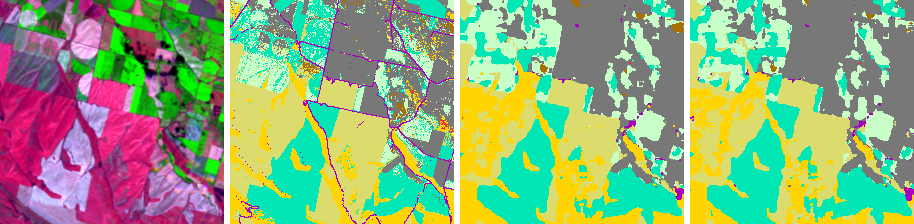

{'chip': 'chip_104_104', 'agreement': 0.522, 'largest_predicted': 'Alfalfa', 'note': 'sanity check on two chips'}
{'chip': 'chip_104_104', 'panels': ['SWIR 2 / NIR / red (middle date)', 'reference (black = no data)', 'frozen class map', 'adapted class map']}


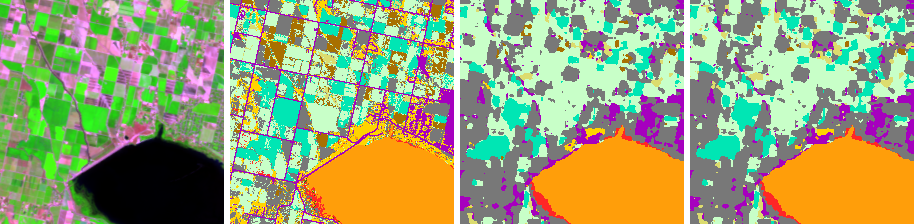

{'legend': {'Natural Vegetation': 'rgb(255, 212, 0)', 'Forest': 'rgb(38, 115, 0)', 'Corn': 'rgb(168, 112, 0)', 'Soybeans': 'rgb(0, 168, 230)', 'Wetlands': 'rgb(255, 38, 38)', 'Developed/Barren': 'rgb(166, 0, 190)', 'Open Water': 'rgb(255, 158, 10)', 'Winter Wheat': 'rgb(0, 230, 180)', 'Alfalfa': 'rgb(120, 120, 120)', 'Fallow/Idle Cropland': 'rgb(220, 220, 110)', 'Cotton': 'rgb(0, 0, 200)', 'Sorghum': 'rgb(140, 70, 20)', 'Other': 'rgb(200, 255, 200)'}}
{'artifact': 'outputs/prithvi_crop_classification_adapter', 'format': 'org.valcorza.prithvi-crop-classification.adapter.v1', 'trainable': 'head', 'tensors': 5, 'bytes': 21249580, 'sha256': '4240b75b05faddf7...'}


{'reload_parity': {'mean_iou_diff': 0.0, 'metrics_identical': True, 'max_abs_score_diff': 0.0}, 'reloaded_best_epoch': 4}


outputs/:
  - outputs/prithvi_crop_classification_adapter/adapter.safetensors (20751.5 KB)
  - outputs/prithvi_crop_classification_adapter/manifest.json (9.6 KB)
  - outputs/prithvi_crop_classification_evaluation_report.json (29.6 KB)
  - outputs/prithvi_crop_classification_map_adapted_chip_061_092.tif (49.2 KB)
  - outputs/prithvi_crop_classification_map_adapted_chip_104_104.tif (49.2 KB)
  - outputs/prithvi_crop_classification_map_reference_chip_061_092.tif (49.2 KB)
  - outputs/prithvi_crop_classification_map_reference_chip_104_104.tif (49.2 KB)
  - outputs/prithvi_crop_classification_maps_chip_061_092.png (173.8 KB)
  - outputs/prithvi_crop_classification_maps_chip_104_104.png (157.2 KB)
  - outputs/prithvi_crop_classification_predictions.json (1.4 KB)
  - outputs/prithvi_crop_classification_result.json (3.6 KB)
  - outputs/prithvi_crop_classification_sample_chip.tif (1764.5 KB)
  - outputs/prithvi_crop_classification_sample_label.tif (49.2 KB)
  - outputs/prithvi_crop_classificati

In [ ]:
import platform
import shutil

import tifffile

shown_records = test_records[:2]
shown_predictions = pipe.predict(shown_records)
# CR-M2: chip_name() works for sample and BYOD records alike. CR-m4: the maps are shown inline, not only written.
for record, pred, frozen_pred in zip(shown_records, shown_predictions['predictions'], frozen_predictions['predictions']):
    name = chip_name(record)
    tifffile.imwrite(f'outputs/prithvi_crop_classification_map_adapted_' + name + '.tif', (pred['mask'].astype(np.int64) + 1).astype(np.uint8))
    tifffile.imwrite(f'outputs/prithvi_crop_classification_map_reference_' + name + '.tif', np.where(record['label'] < 0, 0, record['label'] + 1).astype(np.uint8))
    labelled = record['label'] >= 0
    print({'chip': name, 'agreement': round(float((pred['mask'] == record['label'])[labelled].mean()), 3), 'largest_predicted': max(pred['class_fraction'], key=pred['class_fraction'].get), 'note': 'sanity check on two chips'})
    panel = class_map_panel(record, frozen_pred['mask'], pred['mask'])
    png = render_png(panel['rgb'])
    with open(f'outputs/prithvi_crop_classification_maps_' + name + '.png', 'wb') as f:
        f.write(png)
    print({'chip': name, 'panels': panel['panels']})
    display(PngImage(png, caption=name))
print({'legend': {entry['class']: 'rgb' + str(tuple(entry['rgb'])) for entry in panel['legend']}})
with open('outputs/prithvi_crop_classification_predictions.json', 'w', encoding='utf-8') as f:
    json.dump({'model': shown_predictions['model'], 'classes': shown_predictions['classes'], 'decision_rule': shown_predictions['decision_rule'], 'predictions': [{'id': p['id'], 'class_fraction': p['class_fraction']} for p in shown_predictions['predictions']]}, f, indent=2)

artifact_dir = Path('outputs/prithvi_crop_classification_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'prithvi_crop_classification', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'trainable': artifact_manifest['adapter']['trainable'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...'})

reloaded = PrithviCropPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device)
reloaded_test = reloaded.evaluate(test_records)
before = pipe.predict(test_records[:2])['predictions']
after = reloaded.predict(test_records[:2])['predictions']
parity = {'mean_iou_diff': round(abs(reloaded_test['model']['mean_iou'] - adapted_test['model']['mean_iou']), 6), 'metrics_identical': reloaded_test['model'] == adapted_test['model'], 'max_abs_score_diff': max(float(np.abs(a['scores'] - b['scores']).max()) for a, b in zip(before, after))}
print({'reload_parity': parity, 'reloaded_best_epoch': reloaded.adapter['best_epoch']})
assert parity['mean_iou_diff'] < 1e-3 and parity['max_abs_score_diff'] < 1e-2

result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model': {**evaluation_report['model'], 'model_license': MODEL_LICENSE, 'device': pipe.device, 'source': pipe.source},
    'provenance': {
        'source_asset': [e for e in MANIFEST['files'] if e['path'] == SOURCE_CKPT_NAME],
        'pickle_audit_sha256': PICKLE_AUDIT_SHA256,
        'meta_globals_bound_to_stand_ins': sorted(META_GLOBALS),
        'converted': verify_converted(WEIGHTS_DIR)['files'],
        'pickle_unpickled_once_for_conversion': True,
        'served_from_pickle': False,
        'remote_code_executed': False,
        'network_source': 'modeling.py carried in this notebook (plain PyTorch)',
        'data_tarball': {'name': TAR_NAME, 'sha256': TAR_SHA256, 'pinned_members': 2 * len(SAMPLE_RECORDS)},
        'data_base_url': CORPUS_BASE_URL,
        'data_license': CORPUS_LICENSE,
    },
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'tifffile': tifffile.__version__, 'numpy': np.__version__},
    'data_source': data_source,
    'comparison': comparison,
    'adaptation_gpu_peak_gb': adapt_result['gpu_peak_gb'],
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes']},
    'reload_parity': parity,
}
with open('outputs/prithvi_crop_classification_result.json', 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, indent=2)

print('outputs/:')
for path in sorted(Path('outputs').rglob('*')):
    if path.is_file():
        print(f'  - {path.as_posix()} ({path.stat().st_size / 1024:.1f} KB)')

**What to notice:** in each strip, where the frozen and adapted maps differ and whether those pixels agree with the reference; the agreement of the two class maps with their references; the artifact's size and tensor count; and `reload_parity`.

<details><summary>Check your reasoning</summary>Agreement on two chips is a sanity check, not an evaluation: the strips show the shape of the errors (field edges, the classes the model confuses), and the GeoTIFFs can be opened beside the reference masks in any GIS. In the recorded run the 5-tensor, 21 MB adapter (the head's weights and biases; its BatchNorm buffers are not trained and not exported) reloaded into a fresh pipeline with identical held-out metrics (`mean_iou_diff` 0.0, `metrics_identical` True, `max_abs_score_diff` 0.0).</details>

## Interpretation and limits

On 12 held-out chips the packaged crop-classification model reaches a mean IoU near 0.44 and an accuracy near 0.59 against a majority-class baseline of 0.01 and 0.14; a bounded fine-tuning of its segmentation head on 36 chips, selected by validation loss with the frozen model as a candidate, lowers the class-weighted validation loss a little (0.9368 → 0.9114) and lowers the mean IoU a little (0.4379 → 0.4302 on the test chips, 0.4609 → 0.4451 on validation, in the build record) — and underneath the mean, the per-class table shows the trade the class-weighted loss makes: Natural Vegetation, the majority class, lost a quarter of its IoU (0.2494 → 0.1884) while Fallow/Idle Cropland gained (0.3229 → 0.3784); the loss counts rare classes up to 9× more than common ones, so it buys the rare classes with the common one. That is the claim: the adaptation contract runs end to end on real labelled multispectral time series drawn from a digest-verified tarball, the pickle is audited and converted rather than served, the network is carried in plain PyTorch, and the artifact that carries the change is 21 MB and reloads with the same outputs. It is not a claim that this sample improves the model — the checkpoint was selected on the split these chips come from — nor that 12 chips measure its skill.

The numbers are sample-sanity evidence: one seeded run, 12 test chips, no dispersion estimate, pixel-pooled metrics that let large fields dominate, and labels derived from the Cropland Data Layer with their own errors at field edges and for minor crops. Nothing here measures the model outside the contiguous United States, outside 2022, on other dates, or on chips larger than 224 × 224.

Three things to carry to real data. **The 18 channels and their scaling are the contract:** three dates × six bands — blue, green, red, narrow NIR, SWIR 1, SWIR 2 — date-major, as digital numbers; and the network folds them exactly as its training pipeline did, which is not the (bands, dates) layout the axis names suggest — a different band order or date order is classified without complaint and silently wrong. **Split by region, not by chip:** neighbouring chips share fields, and a random split makes memorisation look like skill. **Read the baseline and the per-class IoU first:** the majority class alone is right on a seventh of the pixels, and a mean IoU hides that Natural Vegetation is barely found while Open Water is easy.

Successful execution proves that the recorded repository revision's pipeline modules, carried in this standalone notebook, can acquire and digest-verify a pickled upstream checkpoint, audit and convert it into safetensors without executing anything outside the audited allow-list, rebuild the network from the carried module, fetch a digest-pinned tarball and extract exactly the pinned labelled chips, execute bounded fine-tuning, evaluate against a baseline and the frozen model on held-out chips, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or crop-mapping skill beyond the checks shown.

## Optional experiment: Predict → Change → Run → Observe → Explain

None of this affects the default path, and every adaptation starts from the pinned base — including after a `head+last_block` run, whose encoder block is put back before the next run — so each run is a fresh experiment rather than continued training. **Scope of a re-run:** change the form field in Section 6, then run Sections 6, 7 and 8 in that order (Section 5 need not be re-run; if you do, it restores the base and prints `restored_pinned_base`). Pick one:

1. **Learning rate.** *Predict:* with `LEARNING_RATE = 1e-4` (ten times the default) on a checkpoint selected on this very split, will any epoch beat the frozen model's class-weighted validation loss (0.9368 in the record), or will epoch 0 be kept? *Change* the field, *run* 6–8, *observe* `best_epoch`, the per-epoch `val_loss` and `val_mean_iou`, and the `per_class_iou_changes`, and *explain* the result in terms of what a larger step does to a head near a minimum. There is no recorded outcome for this setting; your run is the evidence.
2. **Scope.** *Predict:* does `TRAINABLE = 'head+last_block'` (7.1 M more parameters) move the validation mean IoU with the loss, or against it as the head-only run did? *Observe* `trainable_parameters`, `gpu_peak_gb`, the per-epoch rows and the artifact's tensor count (now more than 5).
3. **Epochs.** *Predict:* with `EPOCHS = 10`, does the validation loss keep falling while the validation mean IoU keeps slipping? *Observe* the kept epoch and the per-class changes.
4. **Your own chips.** Set `USE_BYOD = True` with `BYOD_PATH` (a `group` column keeps one field in one role) and re-run from Section 4: read the majority-class baseline and the per-class IoU before the adapted number, and compare the frozen column — the packaged model — with the adapted one.

## Troubleshooting

- **Section 1 stops with "This notebook needs a Linux x86_64 runtime"** — you are on Windows, macOS or an ARM machine. Use Google Colab, Kaggle or a Linux x86_64 Jupyter server.
- **The uv wheel fails its size/SHA-256 check, or a download in Section 1 times out** — run Section 1 again; a complete environment built from the same lock is reused, an incomplete one is finished. If it repeats, the network is blocking or altering `files.pythonhosted.org` or `pypi.org`.
- **"The isolated environment's Python process exited"** — usually out of memory. Restart the session and choose **Run all**.
- **You re-ran Section 1 on its own** — nothing is lost: it keeps the running worker and every variable, so the cells after it keep working. After a session restart, run from the top.
- **Section 3 reports a size or SHA-256 mismatch, or cannot reach the Hub** — the message names the file. Delete it from the snapshot folder Section 3 prints and run Section 3 again.
- **Section 3 stops during the pickle audit or conversion** — the audit refuses any global outside the allow-list and names it; the downloaded checkpoint is not the pinned one. Delete the snapshot folder and run Section 3 again.
- **Section 4 stops on the tarball's size or SHA-256** — the 1.18 GB download was cut short or altered. Run Section 4 again; chips already extracted and verified are reused. If the digest still fails, delete `weights/multi-temporal-crop/` and run it once more.
- **CUDA out of memory in Section 6** — another notebook holds the GPU, or `TRAINABLE = 'head+last_block'` with a larger `BATCH_SIZE` exceeds a T4. Restart the session, keep `BATCH_SIZE = 4`, and choose **Run all**.
- **Section 5 prints `restored_pinned_base`** — you re-ran it after Section 6; the adapted head was put back to the base. Re-run Sections 6–8 in order.
- **BYOD: a band, date, shape or label refusal** — the message names the rule; chips must be 18-band 224 × 224 GeoTIFFs (three dates × six bands, date-major, digital numbers) with masks of 0 = no data and 1..13 = class, and the dataset needs at least two classes.
- **BYOD: "… bring at least 7 chips"** — the seeded split takes 25 % for test and 20 % for validation and must leave 4 training chips, so 7 distinct labelled chips is the minimum (more if a `group` column puts many chips in one group).
- **BYOD: "pairs.csv row … is listed but not in the zip"** or **"… is not a readable GeoTIFF"** — the message names the row and the file; fix the name in `pairs.csv` or replace the file. The sample pair written by Section 4 shows the expected files.
- **BYOD: "chips have no 'group'"** — either give every row a `group` value (a field, scene or region id) or leave the column out.
- **Section 8 shows no strips** — they are also written as `outputs/prithvi_crop_classification_maps_<chip>.png`; on Jupyter make sure the notebook is trusted.
- **BYOD: "BYOD_PATH … does not exist"** — the path is relative to the working directory printed in the message.
- **BYOD: "the upload dialog exists only in Google Colab"** — on Kaggle or Jupyter, put the zip (or folder) in the runtime and set `BYOD_PATH` to its path.
- **BYOD: "Upload exactly one .zip file"** — the dialog was cancelled or several files were chosen; run the cell again.

## Glossary

- **HLS (Harmonized Landsat Sentinel-2):** NASA's surface-reflectance product on one 30 m grid; the six bands here are blue, green, red, narrow NIR, SWIR 1 and SWIR 2.
- **Multi-temporal chip:** the same 224 × 224 area at three dates of one growing season; crops are told apart by how they change over the season.
- **Digital numbers:** reflectance × 10 000 stored as integers, the scale the model's band statistics expect.
- **Cropland Data Layer (CDL):** the USDA's annual crop map, from which the 13 labels were derived; it has its own errors at field edges.
- **Class map / ignore class:** one class per pixel; −1 (0 in the GeoTIFFs) marks no-data pixels that are excluded from training and scoring.
- **Majority-class baseline:** naming every pixel with the most frequent class; the best any constant map can do.
- **Per-class IoU, mean IoU, mean class accuracy:** overlap of predicted and true pixels for one class; its average over the classes present; the average per-class recall.
- **Class weights:** the upstream loss counts rare classes up to 9× more than common ones.
- **Encoder, neck, head:** the temporal ViT that turns patches into features; the transposed convolutions that fold the dates and upsample; the FCN layer that names each pixel.
- **Frozen / adapted / pinned base:** the packaged model; the model after Section 6; the verified packaged weights every adaptation starts from (`restore_base`).
- **Block split / group split:** roles assigned per 4 × 4-chip block so chips of one block never straddle training and test; for your own chips the `group` column of `pairs.csv` does the same for a field, scene or region.
- **Class-weighted loss trade:** a loss that counts rare classes more can lower itself by giving up the common class; the mean IoU barely moves while the per-class row does.
- **Pickle audit / safetensors:** the upstream checkpoint is a pickle that could run code when loaded; it is statically checked against an allow-list and converted once to safetensors, a format that stores only tensors.
- **Isolated environment:** the separate Python environment Section 1 builds from the hash lock; every later cell runs there.

## Conclusion (your notes)

Complete these in your own words; the recorded run's values are in the **Check your reasoning** answers above.

- The frozen model's test mean IoU was ___ against the majority-class baseline's ___; the easiest and hardest classes were ___ and ___.
- Head fine-tuning lowered the validation loss but moved the test mean IoU to ___, and the class that moved most was ___, which I read as ___.
- The number I would not trust on its own is ___, because ___.
- Before adapting on my own chips I would check the band and date order, split by ___, and read ___ first.

## References

- Repository README: https://github.com/kurtvalcorza/prithvi-crop-classification-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/prithvi-crop-classification-pipeline/blob/main/MODEL_CARD.md
- Weights and conversion notes: https://github.com/kurtvalcorza/prithvi-crop-classification-pipeline/blob/main/docs/WEIGHTS.md
- Hugging Face model repository: https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-1.0-100M-multi-temporal-crop-classification (revision `b53a88b8da673800b67c34a98a527b77076e7035`)
- Multi-temporal crop classification dataset: https://huggingface.co/datasets/ibm-nasa-geospatial/multi-temporal-crop-classification (CC BY 4.0)
- Jakubik, J., Roy, S., Phillips, C. E., et al. (2023). Foundation models for generalist geospatial artificial intelligence. arXiv:2310.18660: https://arxiv.org/abs/2310.18660
- Upstream fine-tuning code: https://github.com/NASA-IMPACT/hls-foundation-os (the network is vendored in `modeling.py`)
- DIMER Notebook Specification 2.0 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)